In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\Admin\Desktop\yearly_monthly_averages.csv")
df.head()

,loc_id,year,month,maxtempC,maxtempF,mintempC,mintempF,avgtempC,avgtempF,rainMM,...,avgwindgustKmph,visibilityKm,visibilityMiles,humidity,pressureMB,pressureInches,cloudcover,sun_hour,sun_days,uvindex
0,1,2009,1,17,63,8,46,13,55,41.10,...,13.2,10,5,66,1022.6,30.7,21,275.0,26,5
1,1,2009,2,15,59,8,46,12,54,168.33,...,18.0,9,5,80,1017.3,30.5,46,158.0,20,5
2,1,2009,3,17,63,8,46,14,57,94.70,...,17.0,9,5,76,1018.8,30.6,26,277.0,28,5
3,1,2009,4,20,68,8,47,16,61,34.40,...,15.5,9,5,66,1017.5,30.5,22,291.0,28,5
4,1,2009,5,23,74,11,52,20,68,34.76,...,12.1,9,5,68,1015.2,30.5,22,304.0,27,5


In [3]:
df.tail()

,loc_id,year,month,maxtempC,maxtempF,mintempC,mintempF,avgtempC,avgtempF,rainMM,...,avgwindgustKmph,visibilityKm,visibilityMiles,humidity,pressureMB,pressureInches,cloudcover,sun_hour,sun_days,uvindex
991,6,2022,6,28,83,17,63,24,74,16.0,...,14.8,9,5,64,1014.5,30.4,39,181.0,30,7
992,6,2022,7,33,92,22,71,29,83,14.3,...,14.2,10,5,60,1014.4,30.4,32,236.0,31,7
993,6,2022,8,32,90,22,71,28,83,13.0,...,12.9,10,6,60,1016.1,30.5,33,235.0,31,7
994,6,2022,9,27,80,17,63,23,73,14.9,...,14.2,10,6,59,1017.0,30.5,29,236.0,29,4
995,6,2022,10,18,65,11,52,15,59,17.9,...,15.6,10,5,63,1019.0,30.6,41,203.0,29,4


In [5]:
#pd.set_option('display.max_rows', df.shape[0]+1)
#print(df)

In [6]:
df4 = df[["loc_id","year","month","avgtempF","avgtempC","humidity"]]
df4.head()

,loc_id,year,month,avgtempF,avgtempC,humidity
0,1,2009,1,55,13,66
1,1,2009,2,54,12,80
2,1,2009,3,57,14,76
3,1,2009,4,61,16,66
4,1,2009,5,68,20,68


In [7]:
#pd.set_option('display.max_rows', df4.shape[0]+1)
#print(df4)

In [11]:
import warnings
warnings.filterwarnings('ignore')
df4["VPD"]=(6.1078*np.exp(df4.avgtempC/(234.175 + df4.avgtempC)*17.08085)*(1-df4.humidity/100))/10
#pd.set_option('display.max_rows', df4.shape[0]+1)
#print(df4)
#df4["VPD"].head()
df4.head()

,loc_id,year,month,avgtempF,avgtempC,humidity,VPD
0,1,2009,1,55,13,66,0.509935
1,1,2009,2,54,12,80,0.280878
2,1,2009,3,57,14,76,0.384207
3,1,2009,4,61,16,66,0.619143
4,1,2009,5,68,20,68,0.749439


In [12]:
Mean_VPD_March_PaloAlto = df4[(df4["month"] == 3) & (df4["loc_id"] == 1)]["VPD"].mean()
Mean_VPD_March_PaloAlto

0.4728885791516045

In [13]:
Mean_VPD_April_PaloAlto = df4[(df4["month"] == 4) & (df4["loc_id"] == 1)]["VPD"].mean()
Mean_VPD_April_PaloAlto

0.5810670238546052

In [14]:
Mean_Humidity_March_PaloAlto = df4[(df4["month"] == 3) & (df4["loc_id"] == 1)]["humidity"].mean()
Mean_Humidity_March_PaloAlto

71.14285714285714

In [15]:
Mean_Humidity_April_PaloAlto = df4[(df4["month"] == 4) & (df4["loc_id"] == 1)]["humidity"].mean()
Mean_Humidity_April_PaloAlto

68.71428571428571

In [16]:
Mean_Temperature_March_PaloAlto = df4[(df4["month"] == 3) & (df4["loc_id"] == 1)]["avgtempF"].mean()
Mean_Temperature_March_PaloAlto

57.785714285714285

In [17]:
Mean_Temperature_April_PaloAlto = df4[(df4["month"] == 4) & (df4["loc_id"] == 1)]["avgtempF"].mean()
Mean_Temperature_April_PaloAlto

60.92857142857143

In [18]:
Describe_PaloAlto = df4[(df4["loc_id"] == 1)].describe()
Describe_PaloAlto

,loc_id,year,month,avgtempF,avgtempC,humidity,VPD
count,166.0,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000
mean,1.0,2015.421687,6.439759,64.228916,17.891566,66.150602,0.739696
std,0.0,4.003394,3.438549,7.722184,4.273986,8.120022,0.321977
min,1.0,2009.000000,1.000000,51.000000,11.000000,41.000000,0.196614
25%,1.0,2012.000000,3.250000,57.250000,14.000000,60.250000,0.513448
50%,1.0,2015.000000,6.000000,64.000000,18.000000,67.000000,0.669310
75%,1.0,2019.000000,9.000000,71.750000,22.000000,72.000000,0.907270
max,1.0,2022.000000,12.000000,78.000000,26.000000,86.000000,1.575794


In [19]:
df5 = df4.loc[df4['loc_id'] == 1]
#pd.set_option('display.max_rows', df5.shape[0]+1)
#print(df5)

In [20]:
Avg_VPD_2009 = df5[(df5["year"] == 2009)]["VPD"].mean()
Avg_VPD_2009

0.709915483064774

In [21]:
Avg_VPD_2010 = df5[(df5["year"] == 2010)]["VPD"].mean()
Avg_VPD_2010

0.537886866518473

In [22]:
Avg_VPD_2011 = df5[(df5["year"] == 2011)]["VPD"].mean()
Avg_VPD_2011

0.5139211017473276

In [23]:
Avg_VPD_2012 = df5[(df5["year"] == 2012)]["VPD"].mean()
Avg_VPD_2012

0.522461417976729

In [24]:
Avg_VPD_2013 = df5[(df5["year"] == 2013)]["VPD"].mean()
Avg_VPD_2013

0.6208289611875767

In [25]:
Avg_VPD_2014 = df5[(df5["year"] == 2014)]["VPD"].mean()
Avg_VPD_2014

0.6262116475061473

In [26]:
Avg_VPD_2015 = df5[(df5["year"] == 2015)]["VPD"].mean()
Avg_VPD_2015

0.7183381074553106

In [27]:
Avg_VPD_2016 = df5[(df5["year"] == 2016)]["VPD"].mean()
Avg_VPD_2016

0.6454016416370916

In [28]:
Avg_VPD_2017 = df5[(df5["year"] == 2017)]["VPD"].mean()
Avg_VPD_2017

0.8897586867316719

In [29]:
Avg_VPD_2018 = df5[(df5["year"] == 2018)]["VPD"].mean()
Avg_VPD_2018

0.9624273145448604

In [30]:
Avg_VPD_2019 = df5[(df5["year"] == 2019)]["VPD"].mean()
Avg_VPD_2019

0.9209546575978299

In [31]:
Avg_VPD_2020 = df5[(df5["year"] == 2020)]["VPD"].mean()
Avg_VPD_2020

0.9549457959105102

In [32]:
Avg_VPD_2021 = df5[(df5["year"] == 2021)]["VPD"].mean()
Avg_VPD_2021

0.8649525881784864

In [33]:
Avg_VPD_2022 = df5[(df5["year"] == 2022)]["VPD"].mean()
Avg_VPD_2022

0.8933402650894383

In [34]:
data55 = [[2009, 0.709915483064774], [2010,0.537886866518473 ], [2011,0.5139211017473276 ],[2012,0.522461417976729],[2013,0.6208289611875767],[2014,0.6262116475061473],[2015,0.7183381074553106],[2016,0.6454016416370916],[2017,0.8897586867316719],[2018,0.9624273145448604],[2019,0.9209546575978299],[2020,0.9549457959105102],[2021,0.8649525881784864],[2022,0.8933402650894383]]
df55 = pd.DataFrame(data55, columns=['year', 'Mean_VPD'])
df55

,year,Mean_VPD
0,2009,0.709915
1,2010,0.537887
2,2011,0.513921
3,2012,0.522461
4,2013,0.620829
5,2014,0.626212
6,2015,0.718338
7,2016,0.645402
8,2017,0.889759
9,2018,0.962427


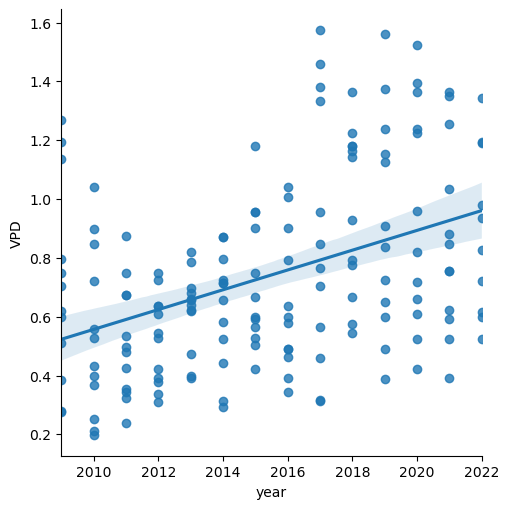

In [35]:
sns.lmplot(x= "year", y = "VPD", data = df5)

<AxesSubplot:>

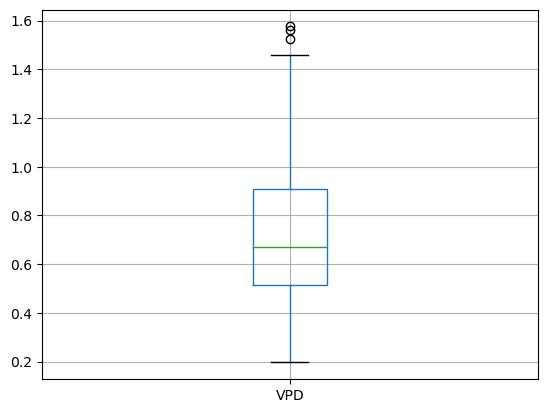

In [36]:
df5.boxplot(column = ["VPD"])

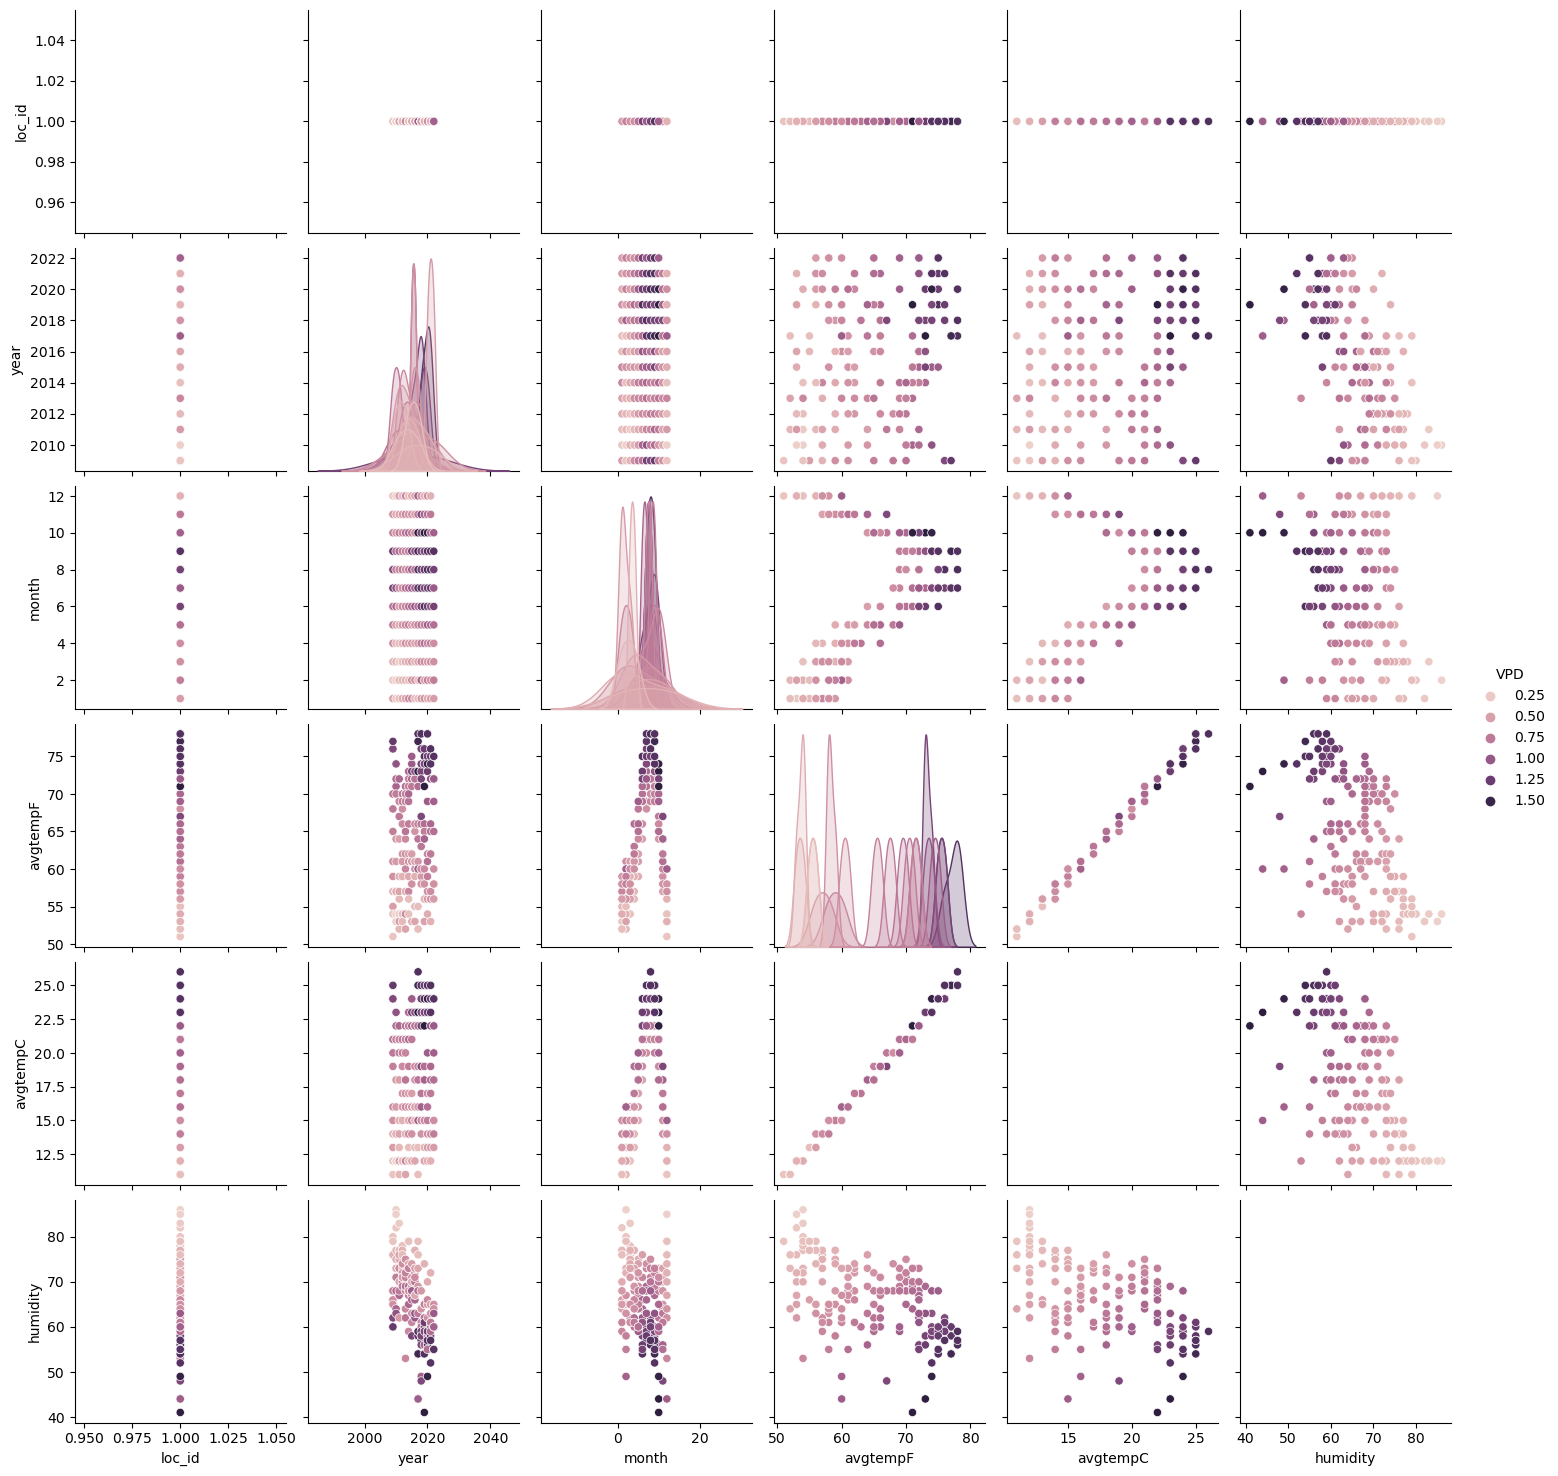

In [37]:
sns.pairplot(data = df5, hue = 'VPD')
plt.show()

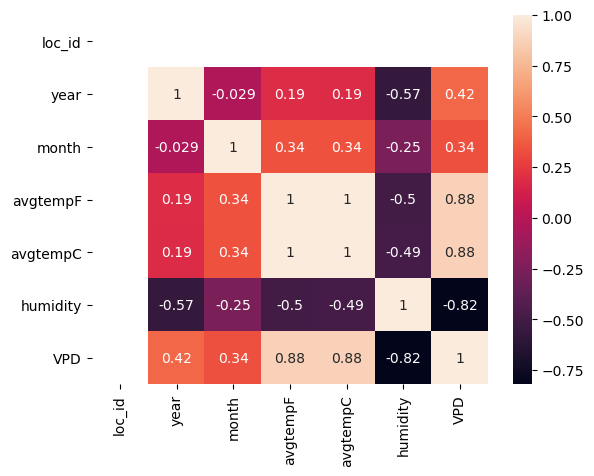

In [38]:
sns.heatmap(df5.corr(), annot = True)
plt.show()

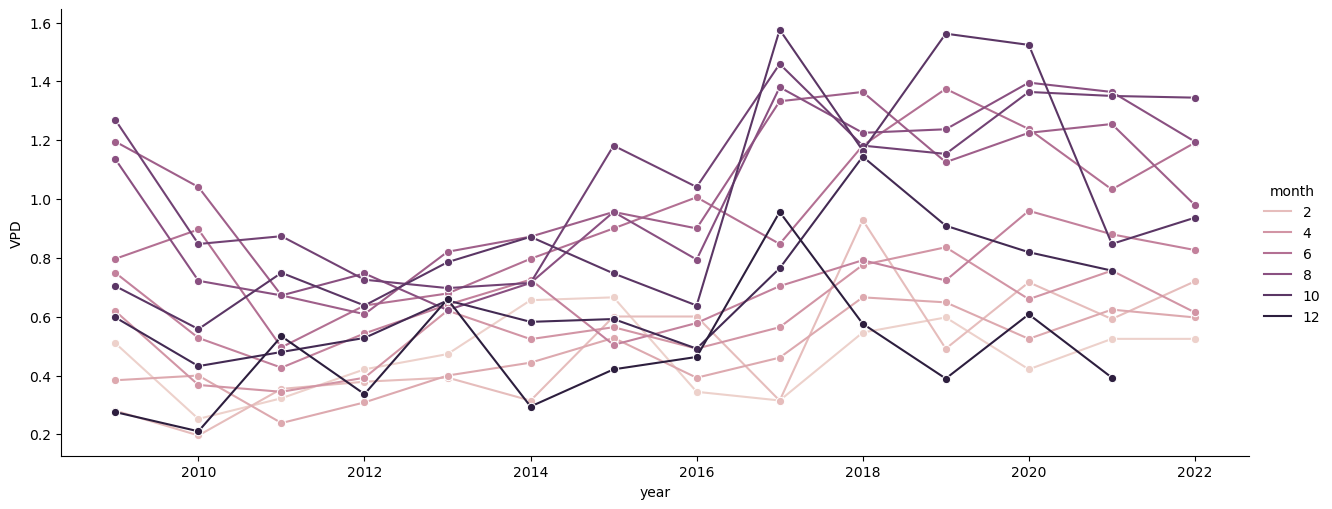

In [39]:
sns.relplot(kind='line', data=df5, x='year', y='VPD', hue='month', aspect=2.5, marker='o')

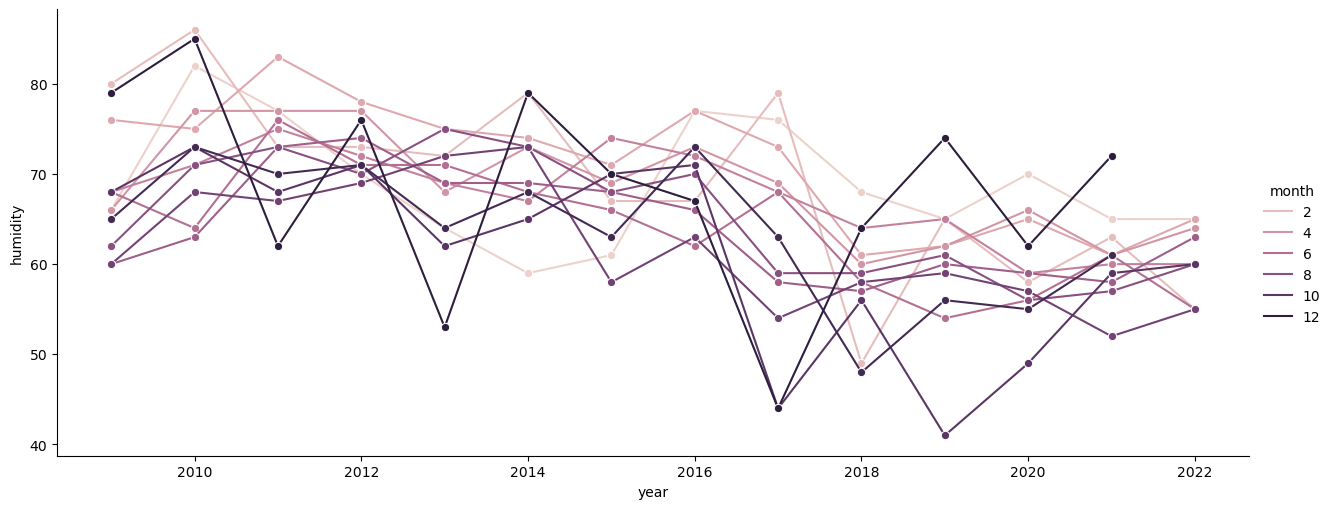

In [40]:
sns.relplot(kind='line', data=df5, x='year', y='humidity', hue='month', aspect=2.5, marker='o')

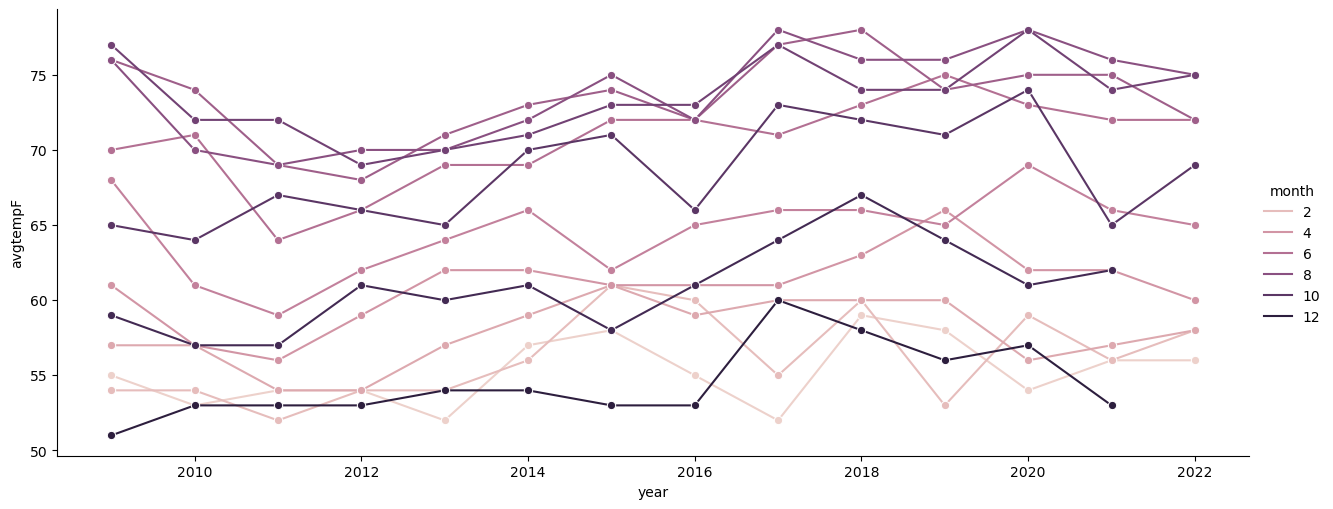

In [41]:
sns.relplot(kind='line', data=df5, x='year', y='avgtempF', hue='month', aspect=2.5, marker='o')

In [42]:
Mean_VPD_March_JohnsonCity = df4[(df4["month"] == 3) & (df4["loc_id"] == 2)]["VPD"].mean()
Mean_VPD_March_JohnsonCity

0.1344935935982688

In [43]:
Mean_VPD_April_JohnsonCity = df4[(df4["month"] == 4) & (df4["loc_id"] == 2)]["VPD"].mean()
Mean_VPD_April_JohnsonCity

0.2330628537795296

In [44]:
Mean_Humidity_March_JohnsonCity = df4[(df4["month"] == 3) & (df4["loc_id"] == 2)]["humidity"].mean()
Mean_Humidity_March_JohnsonCity

82.07142857142857

In [45]:
Mean_Humidity_April_JohnsonCity = df4[(df4["month"] == 4) & (df4["loc_id"] == 2)]["humidity"].mean()
Mean_Humidity_April_JohnsonCity

79.35714285714286

In [46]:
Mean_Temperature_March_JohnsonCity = df4[(df4["month"] == 3) & (df4["loc_id"] == 2)]["avgtempF"].mean()
Mean_Temperature_March_JohnsonCity

35.42857142857143

In [47]:
Mean_Temperature_April_JohnsonCity = df4[(df4["month"] == 4) & (df4["loc_id"] == 2)]["avgtempF"].mean()
Mean_Temperature_April_JohnsonCity

46.92857142857143

In [48]:
Describe_JohnsonCity = df4[(df4["loc_id"] == 2)].describe()
Describe_JohnsonCity

,loc_id,year,month,avgtempF,avgtempC,humidity,VPD
count,166.0,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000
mean,2.0,2015.421687,6.439759,49.500000,9.783133,81.753012,0.283294
std,0.0,4.003394,3.438549,17.716539,9.870124,4.958539,0.199628
min,2.0,2009.000000,1.000000,13.000000,-10.000000,71.000000,0.005702
25%,2.0,2012.000000,3.250000,32.250000,0.250000,79.000000,0.098837
50%,2.0,2015.000000,6.000000,50.000000,10.000000,81.500000,0.228766
75%,2.0,2019.000000,9.000000,66.000000,19.000000,85.000000,0.443778
max,2.0,2022.000000,12.000000,77.000000,25.000000,98.000000,0.920098


In [49]:
df6 = df4.loc[df4['loc_id'] == 2]
#pd.set_option('display.max_rows', df6.shape[0]+1)
#print(df6)

In [50]:
Avg_VPD_2009 = df6[(df6["year"] == 2009)]["VPD"].mean()
Avg_VPD_2009

0.30806033250596565

In [51]:
Avg_VPD_2010 = df6[(df6["year"] == 2010)]["VPD"].mean()
Avg_VPD_2010

0.34145767992953124

In [52]:
Avg_VPD_2011 = df6[(df6["year"] == 2011)]["VPD"].mean()
Avg_VPD_2011

0.26202642356516104

In [53]:
Avg_VPD_2012 = df6[(df6["year"] == 2012)]["VPD"].mean()
Avg_VPD_2012

0.3223432936749442

In [54]:
Avg_VPD_2013 = df6[(df6["year"] == 2013)]["VPD"].mean()
Avg_VPD_2013

0.27463268888606435

In [55]:
Avg_VPD_2014 = df6[(df6["year"] == 2014)]["VPD"].mean()
Avg_VPD_2014

0.2718895393222744

In [56]:
Avg_VPD_2015 = df6[(df6["year"] == 2015)]["VPD"].mean()
Avg_VPD_2015

0.27887772223095714

In [57]:
Avg_VPD_2016 = df6[(df6["year"] == 2016)]["VPD"].mean()
Avg_VPD_2016

0.2797302467506799

In [58]:
Avg_VPD_2017 = df6[(df6["year"] == 2017)]["VPD"].mean()
Avg_VPD_2017

0.2612405794292783

In [59]:
Avg_VPD_2018 = df6[(df6["year"] == 2018)]["VPD"].mean()
Avg_VPD_2018

0.24376594625424222

In [60]:
Avg_VPD_2019 = df6[(df6["year"] == 2019)]["VPD"].mean()
Avg_VPD_2019

0.2642260197951129

In [61]:
Avg_VPD_2020 = df6[(df6["year"] == 2020)]["VPD"].mean()
Avg_VPD_2020

0.263076383099727

In [62]:
Avg_VPD_2021 = df6[(df6["year"] == 2021)]["VPD"].mean()
Avg_VPD_2021

0.2531751994039206

In [63]:
Avg_VPD_2022 = df6[(df6["year"] == 2022)]["VPD"].mean()
Avg_VPD_2022

0.35328438293755254

In [64]:
data66 = [[2009, 0.30806033250596565], [2010,0.34145767992953124 ], [2011,0.26202642356516104 ],[2012,0.3223432936749442],[2013,0.27463268888606435],[2014,0.2718895393222744],[2015,0.27887772223095714],[2016,0.2797302467506799],[2017,0.2612405794292783],[2018,0.24376594625424222],[2019,0.2642260197951129],[2020,0.263076383099727],[2021,0.2531751994039206],[2022,0.35328438293755254]]
df66 = pd.DataFrame(data66, columns=['year', 'Mean_VPD'])
df66

,year,Mean_VPD
0,2009,0.308060
1,2010,0.341458
2,2011,0.262026
3,2012,0.322343
4,2013,0.274633
5,2014,0.271890
6,2015,0.278878
7,2016,0.279730
8,2017,0.261241
9,2018,0.243766


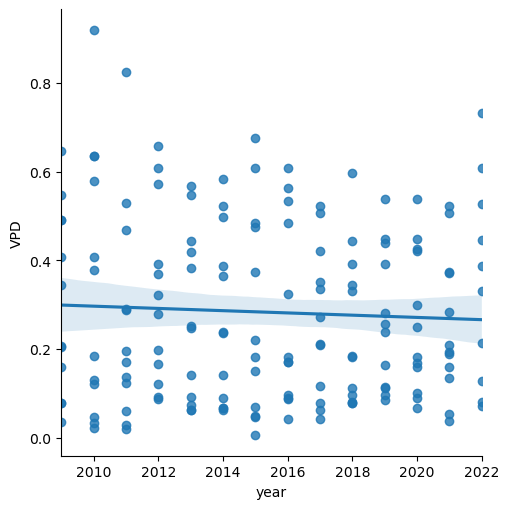

In [65]:
sns.lmplot(x= "year", y = "VPD", data = df6)

<AxesSubplot:>

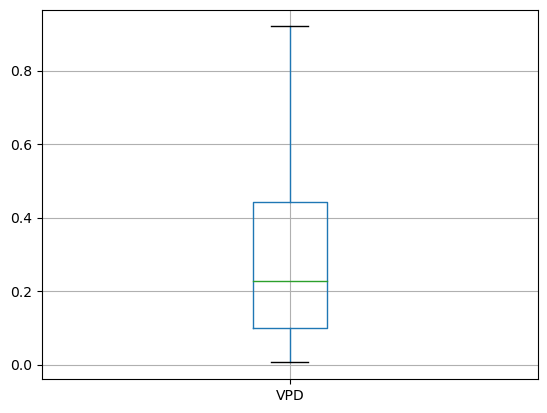

In [66]:
df6.boxplot(column = ["VPD"])

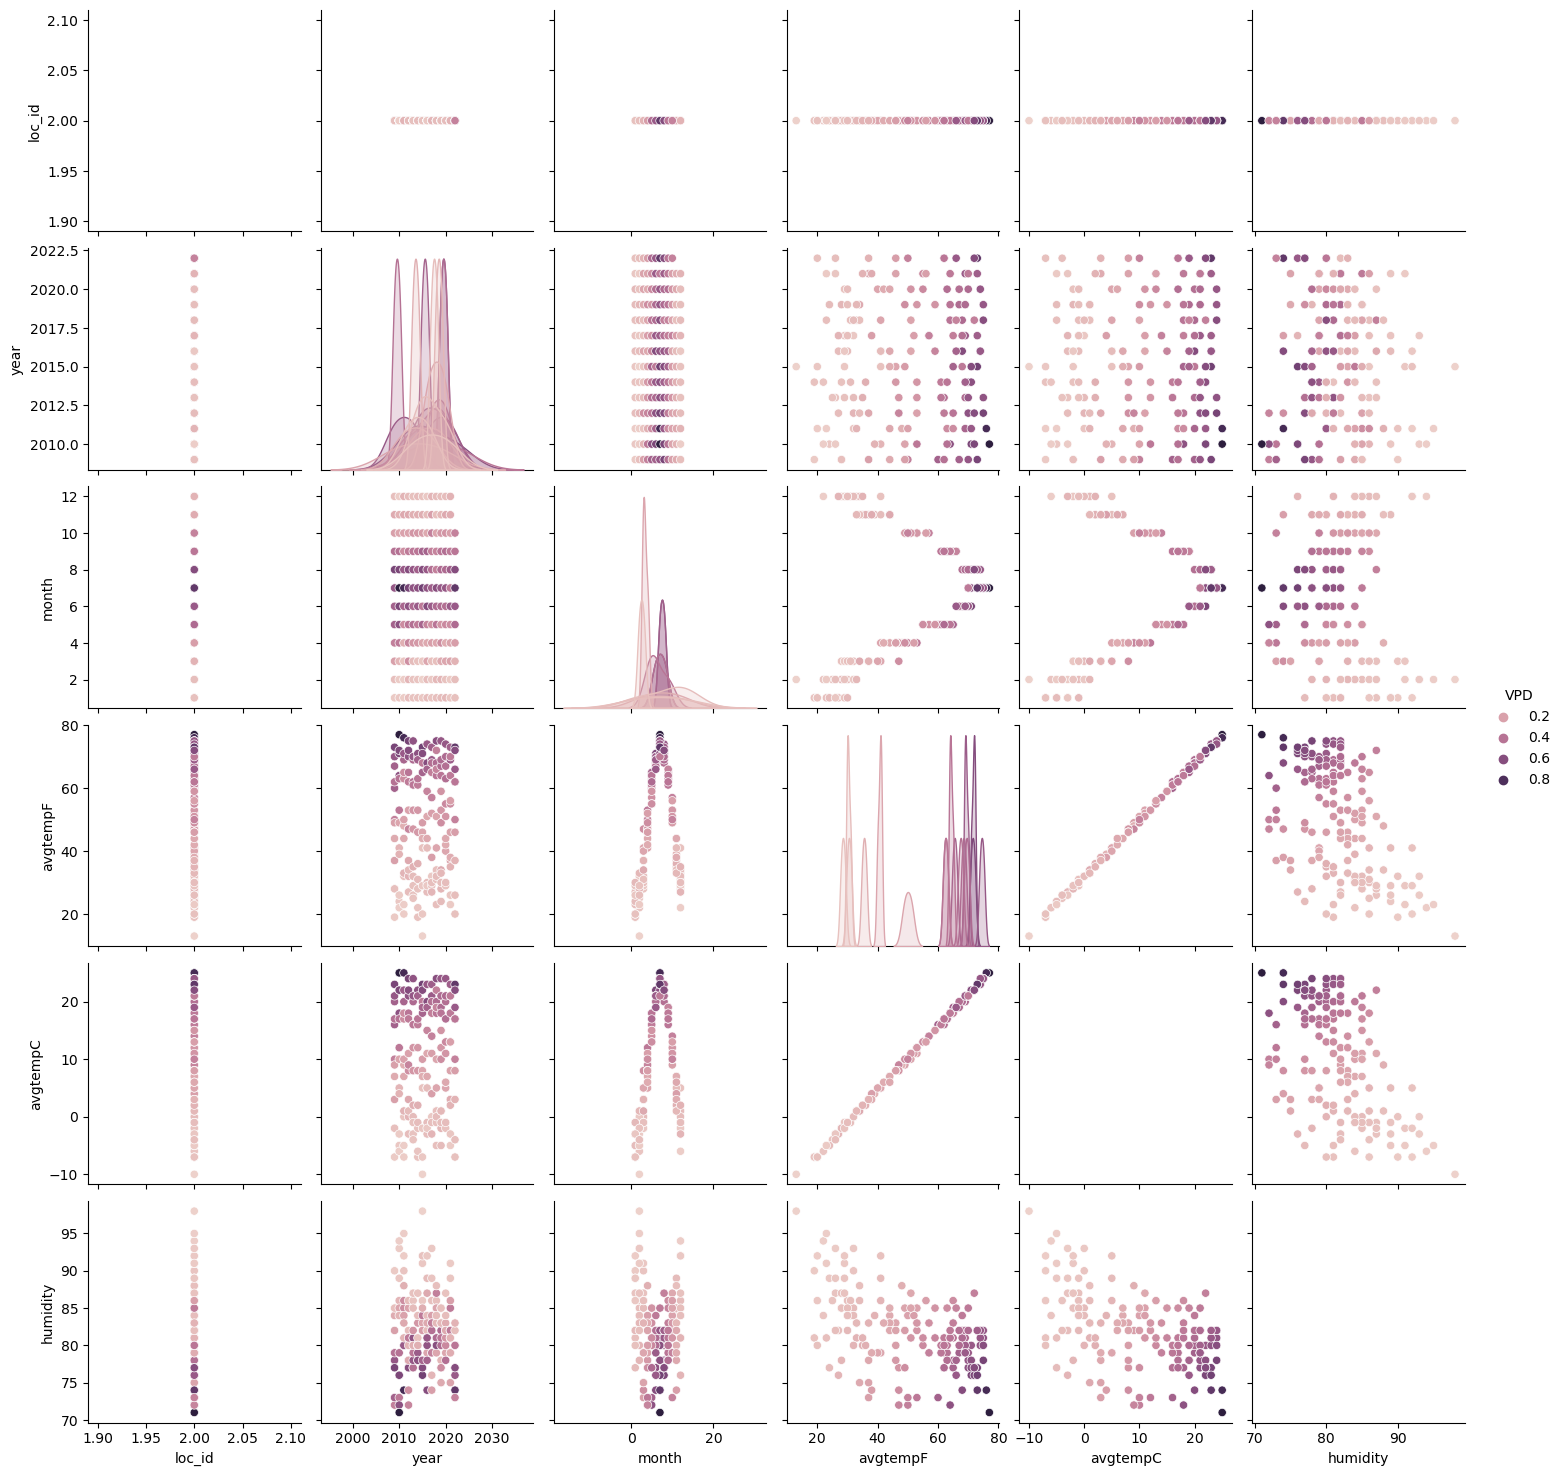

In [67]:
sns.pairplot(data = df6, hue = 'VPD')
plt.show()

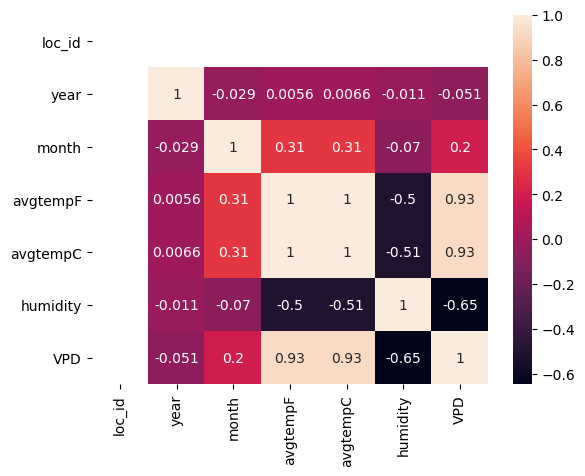

In [68]:
sns.heatmap(df6.corr(), annot = True)
plt.show()

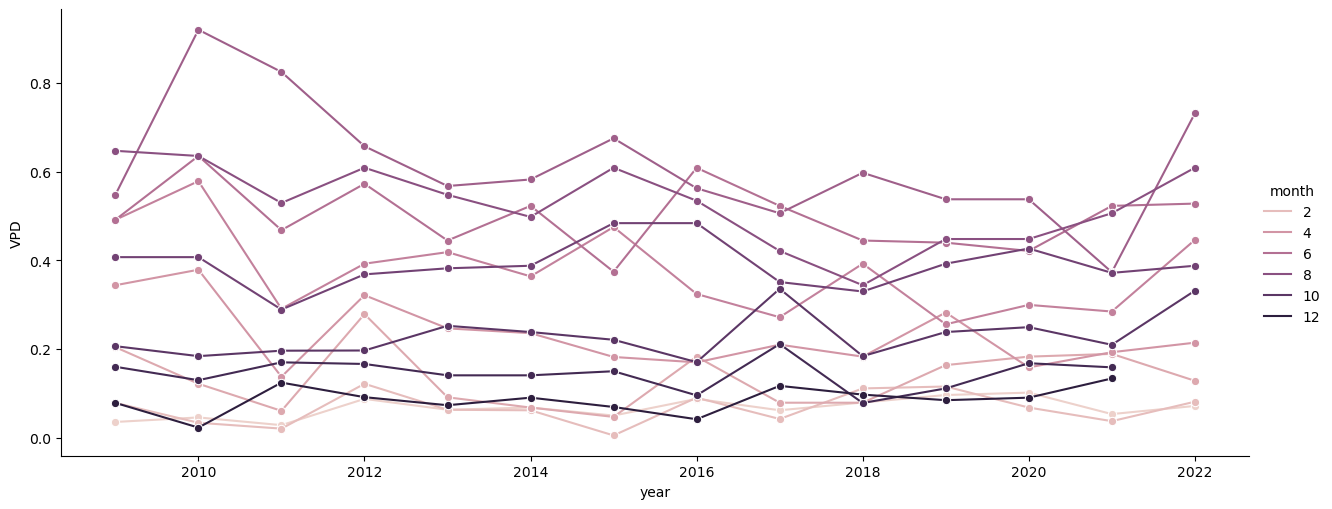

In [69]:
sns.relplot(kind='line', data=df6, x='year', y='VPD', hue='month', aspect=2.5, marker='o')

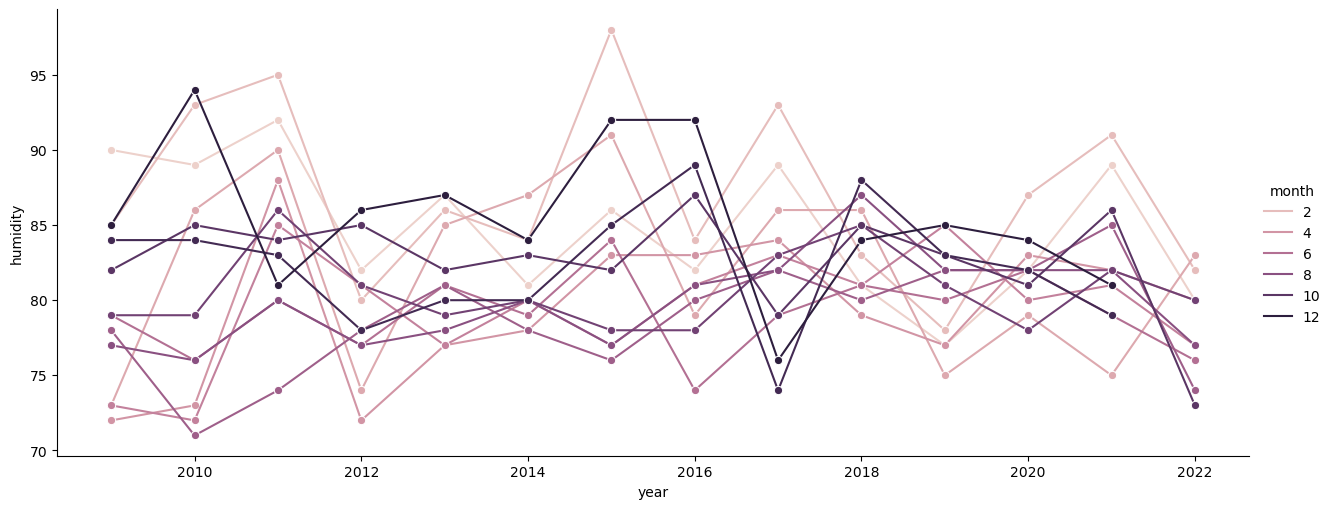

In [70]:
sns.relplot(kind='line', data=df6, x='year', y='humidity', hue='month', aspect=2.5, marker='o')

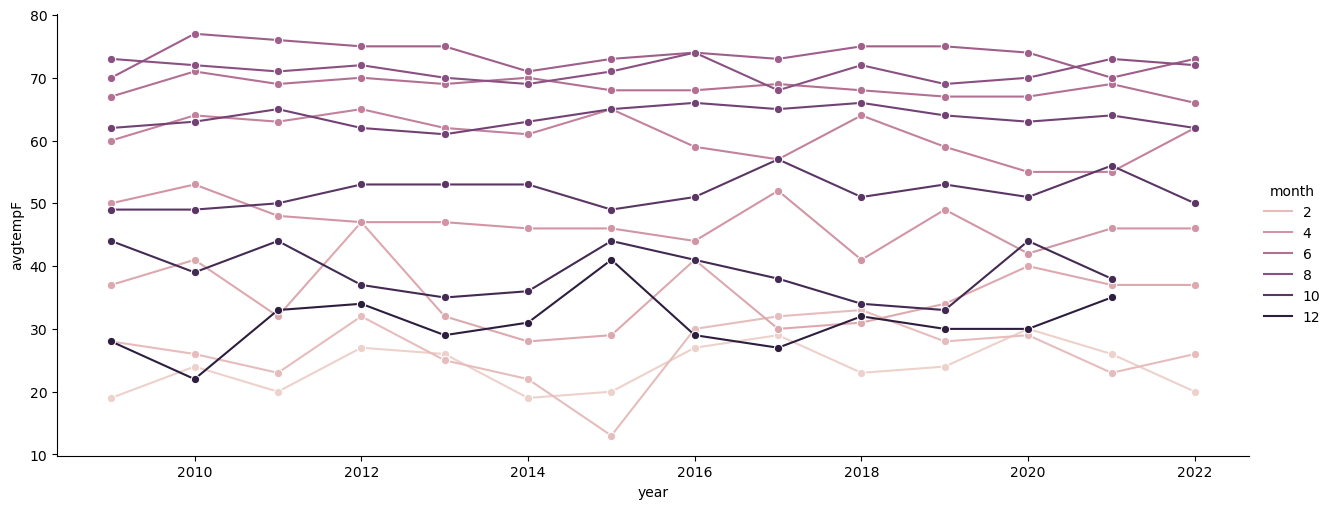

In [71]:
sns.relplot(kind='line', data=df6, x='year', y='avgtempF', hue='month', aspect=2.5, marker='o')

In [72]:
Mean_VPD_March_Marquette = df4[(df4["month"] == 3) & (df4["loc_id"] == 3)]["VPD"].mean()
Mean_VPD_March_Marquette

0.06695946300791147

In [73]:
Mean_VPD_April_Marquette = df4[(df4["month"] == 4) & (df4["loc_id"] == 3)]["VPD"].mean()
Mean_VPD_April_Marquette

0.15066030867912858

In [74]:
Mean_Humidity_March_Marquette = df4[(df4["month"] == 3) & (df4["loc_id"] == 3)]["humidity"].mean()
Mean_Humidity_March_Marquette

87.71428571428571

In [75]:
Mean_Humidity_April_Marquette = df4[(df4["month"] == 4) & (df4["loc_id"] == 3)]["humidity"].mean()
Mean_Humidity_April_Marquette

81.35714285714286

In [76]:
Mean_Temperature_March_Marquette = df4[(df4["month"] == 3) & (df4["loc_id"] == 3)]["avgtempF"].mean()
Mean_Temperature_March_Marquette

27.857142857142858

In [77]:
Mean_Temperature_April_Marquette = df4[(df4["month"] == 4) & (df4["loc_id"] == 3)]["avgtempF"].mean()
Mean_Temperature_April_Marquette

37.92857142857143

In [78]:
Describe_Marquette = df4[(df4["loc_id"] == 3)].describe()
Describe_Marquette

,loc_id,year,month,avgtempF,avgtempC,humidity,VPD
count,166.0,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000
mean,3.0,2015.421687,6.439759,42.945783,6.072289,80.783133,0.255858
std,0.0,4.003394,3.438549,18.393100,10.236930,7.023852,0.205653
min,3.0,2009.000000,1.000000,7.000000,-14.000000,64.000000,0.012369
25%,3.0,2012.000000,3.250000,25.000000,-4.000000,76.000000,0.057241
50%,3.0,2015.000000,6.000000,42.000000,5.000000,80.500000,0.185335
75%,3.0,2019.000000,9.000000,60.000000,16.000000,86.000000,0.424923
max,3.0,2022.000000,12.000000,71.000000,22.000000,96.000000,0.794447


In [79]:
df7 = df4.loc[df4['loc_id'] == 3]
#pd.set_option('display.max_rows', df7.shape[0]+1)
#print(df7)

In [80]:
Avg_VPD_2009 = df7[(df7["year"] == 2009)]["VPD"].mean()
Avg_VPD_2009

0.2219388928241207

In [81]:
Avg_VPD_2010 = df7[(df7["year"] == 2010)]["VPD"].mean()
Avg_VPD_2010

0.2534502951064229

In [82]:
Avg_VPD_2011 = df7[(df7["year"] == 2011)]["VPD"].mean()
Avg_VPD_2011

0.21990354232084428

In [83]:
Avg_VPD_2012 = df7[(df7["year"] == 2012)]["VPD"].mean()
Avg_VPD_2012

0.26266854436283277

In [84]:
Avg_VPD_2013 = df7[(df7["year"] == 2013)]["VPD"].mean()
Avg_VPD_2013

0.19611376003211842

In [85]:
Avg_VPD_2014 = df7[(df7["year"] == 2014)]["VPD"].mean()
Avg_VPD_2014

0.18449425626675717

In [86]:
Avg_VPD_2015 = df7[(df7["year"] == 2015)]["VPD"].mean()
Avg_VPD_2015

0.28336833063446665

In [87]:
Avg_VPD_2016 = df7[(df7["year"] == 2016)]["VPD"].mean()
Avg_VPD_2016

0.2549178479337478

In [88]:
Avg_VPD_2017 = df7[(df7["year"] == 2017)]["VPD"].mean()
Avg_VPD_2017

0.25028480729054664

In [89]:
Avg_VPD_2018 = df7[(df7["year"] == 2018)]["VPD"].mean()
Avg_VPD_2018

0.3064005490022191

In [90]:
Avg_VPD_2019 = df7[(df7["year"] == 2019)]["VPD"].mean()
Avg_VPD_2019

0.26595092300120815

In [91]:
Avg_VPD_2020 = df7[(df7["year"] == 2020)]["VPD"].mean()
Avg_VPD_2020

0.2692602553117607

In [92]:
Avg_VPD_2021 = df7[(df7["year"] == 2021)]["VPD"].mean()
Avg_VPD_2021

0.3087268048015445

In [93]:
Avg_VPD_2022 = df7[(df7["year"] == 2022)]["VPD"].mean()
Avg_VPD_2022

0.31427623258958964

In [94]:
data77 = [[2009, 0.2219388928241207], [2010,0.2534502951064229 ], [2011,0.21990354232084428 ],[2012,0.26266854436283277],[2013,0.19611376003211842],[2014,0.18449425626675717],[2015,0.28336833063446665],[2016,0.2549178479337478],[2017,0.25028480729054664],[2018,0.3064005490022191],[2019,0.26595092300120815],[2020,0.2692602553117607],[2021,0.3087268048015445],[2022,0.31427623258958964]]
df77 = pd.DataFrame(data77, columns=['year', 'Mean_VPD'])
df77

,year,Mean_VPD
0,2009,0.221939
1,2010,0.253450
2,2011,0.219904
3,2012,0.262669
4,2013,0.196114
5,2014,0.184494
6,2015,0.283368
7,2016,0.254918
8,2017,0.250285
9,2018,0.306401


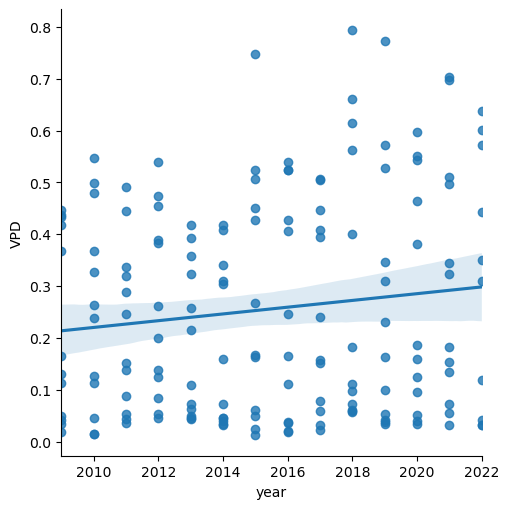

In [95]:
sns.lmplot(x= "year", y = "VPD", data = df7)

<AxesSubplot:>

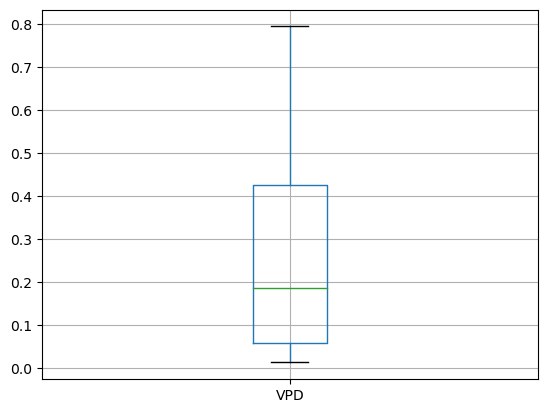

In [96]:
df7.boxplot(column = ["VPD"])

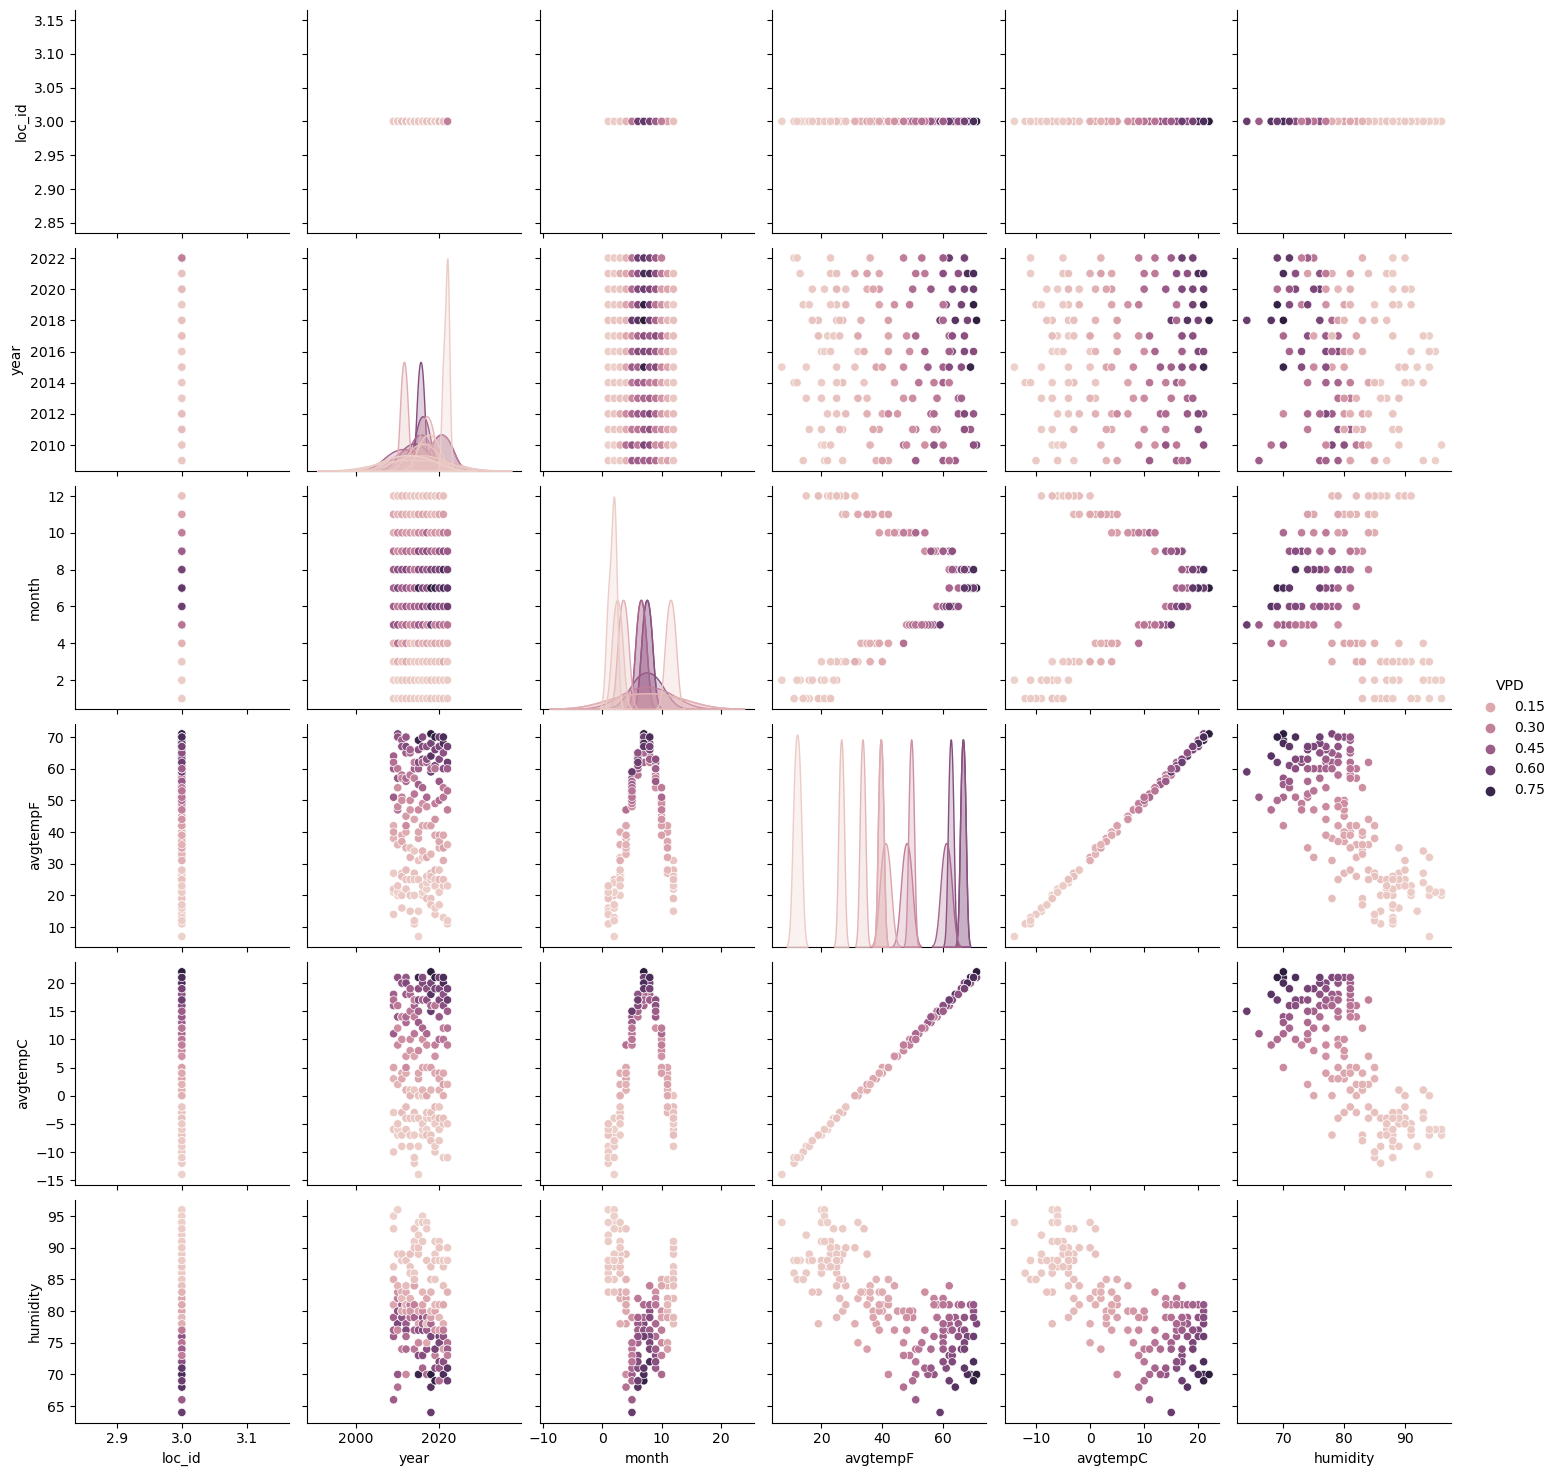

In [97]:
sns.pairplot(data = df7, hue = 'VPD')
plt.show()

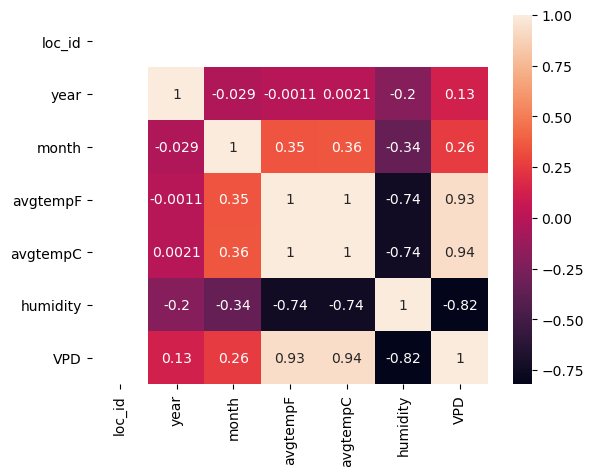

In [98]:
sns.heatmap(df7.corr(), annot = True)
plt.show()

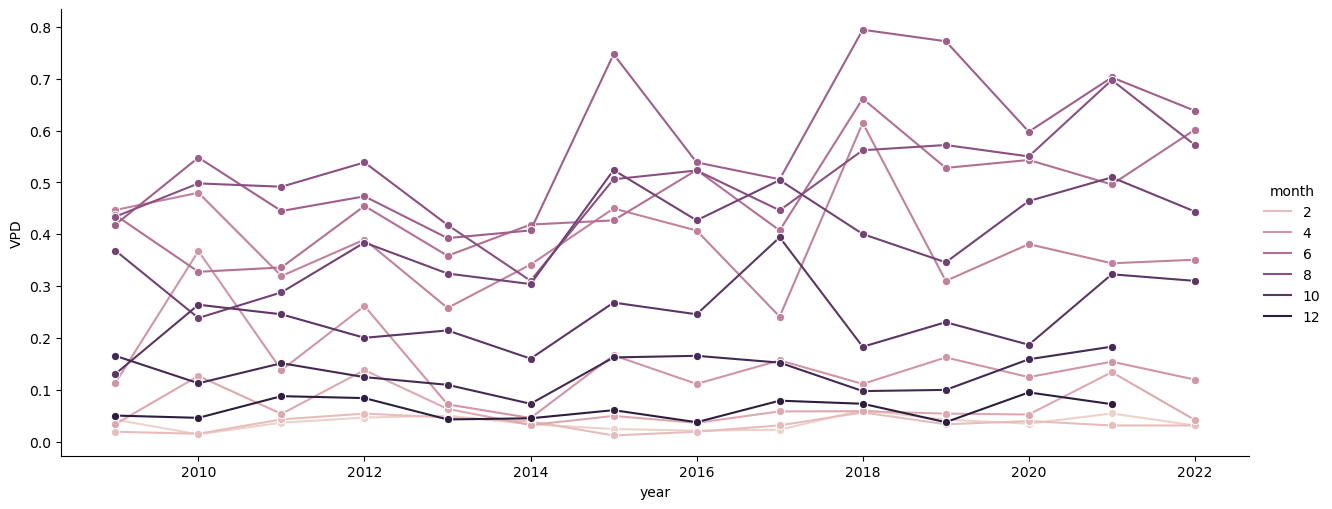

In [99]:
sns.relplot(kind='line', data=df7, x='year', y='VPD', hue='month', aspect=2.5, marker='o')

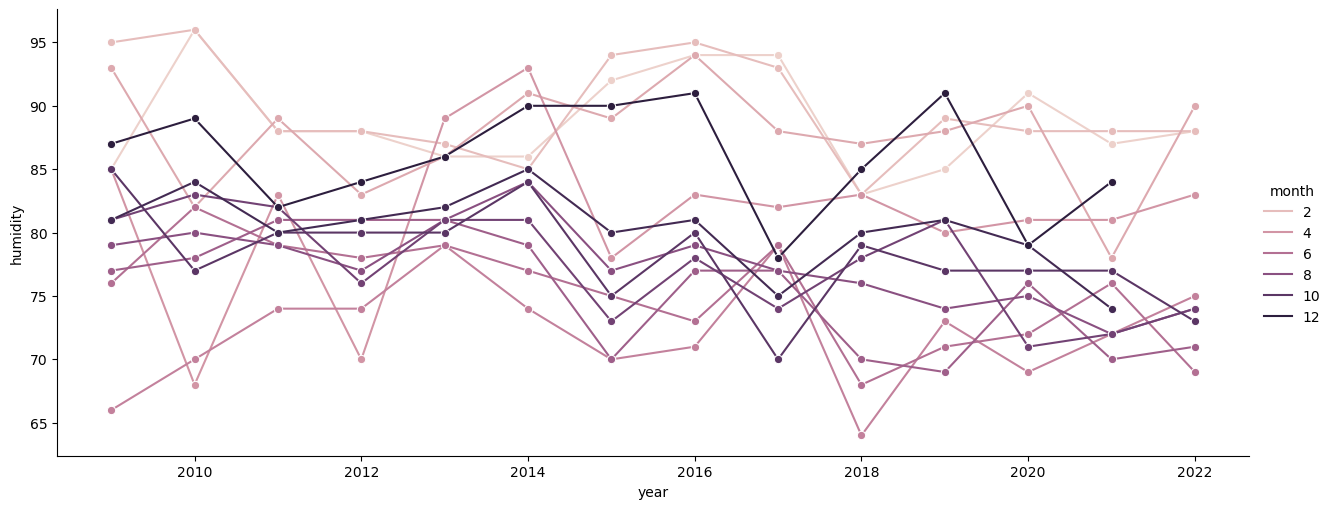

In [100]:
sns.relplot(kind='line', data=df7, x='year', y='humidity', hue='month', aspect=2.5, marker='o')

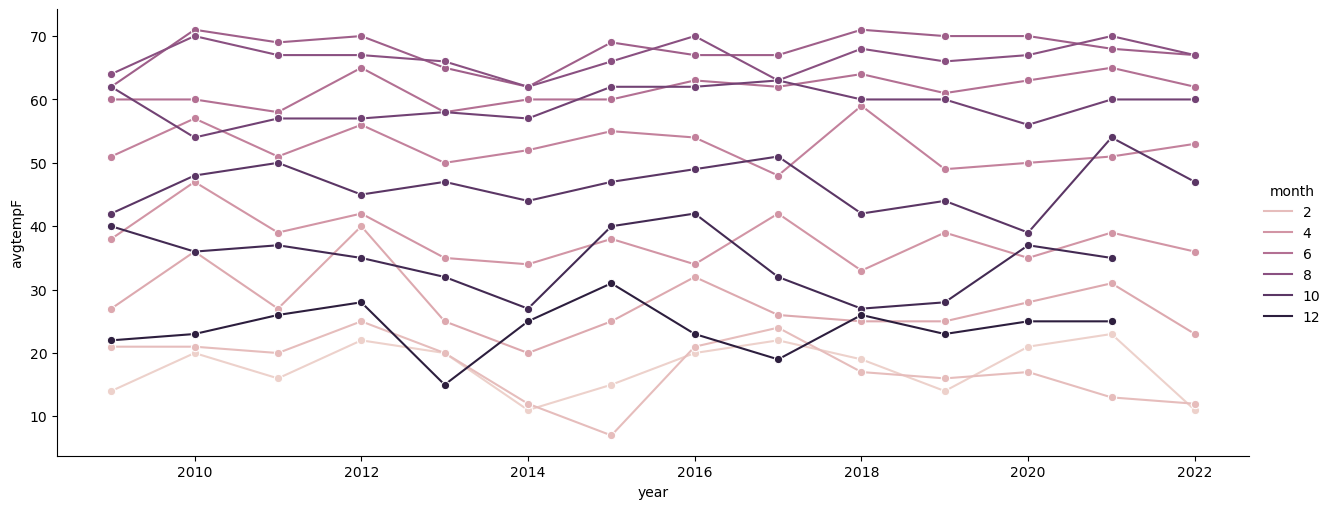

In [101]:
sns.relplot(kind='line', data=df7, x='year', y='avgtempF', hue='month', aspect=2.5, marker='o')

In [102]:
Mean_VPD_March_Madison = df4[(df4["month"] == 3) & (df4["loc_id"] == 4)]["VPD"].mean()
Mean_VPD_March_Madison

0.15479032205735108

In [103]:
Mean_VPD_April_Madison = df4[(df4["month"] == 4) & (df4["loc_id"] == 4)]["VPD"].mean()
Mean_VPD_April_Madison

0.2629353616902342

In [104]:
Mean_Humidity_March_Madison = df4[(df4["month"] == 3) & (df4["loc_id"] == 4)]["humidity"].mean()
Mean_Humidity_March_Madison

79.28571428571429

In [105]:
Mean_Humidity_April_Madison = df4[(df4["month"] == 4) & (df4["loc_id"] == 4)]["humidity"].mean()
Mean_Humidity_April_Madison

76.57142857142857

In [106]:
Mean_Temperature_March_Madison = df4[(df4["month"] == 3) & (df4["loc_id"] == 4)]["avgtempF"].mean()
Mean_Temperature_March_Madison

36.0

In [107]:
Mean_Temperature_April_Madison = df4[(df4["month"] == 4) & (df4["loc_id"] == 4)]["avgtempF"].mean()
Mean_Temperature_April_Madison

46.785714285714285

In [108]:
Describe_Madison = df4[(df4["loc_id"] == 4)].describe()
Describe_Madison

,loc_id,year,month,avgtempF,avgtempC,humidity,VPD
count,166.0,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000
mean,4.0,2015.421687,6.439759,48.307229,9.084337,81.210843,0.277897
std,0.0,4.003394,3.438549,19.669286,10.955231,6.624848,0.186853
min,4.0,2009.000000,1.000000,10.000000,-12.000000,58.000000,0.011693
25%,4.0,2012.000000,3.250000,31.000000,-0.750000,77.000000,0.114701
50%,4.0,2015.000000,6.000000,49.000000,10.000000,81.000000,0.276010
75%,4.0,2019.000000,9.000000,68.000000,20.000000,86.000000,0.417678
max,4.0,2022.000000,12.000000,77.000000,25.000000,97.000000,0.846932


In [109]:
df8 = df4.loc[df4['loc_id'] == 4]
#pd.set_option('display.max_rows', df8.shape[0]+1)
#print(df8)

In [110]:
Avg_VPD_2009 = df8[(df8["year"] == 2009)]["VPD"].mean()
Avg_VPD_2009

0.25680056536887425

In [111]:
Avg_VPD_2010 = df8[(df8["year"] == 2010)]["VPD"].mean()
Avg_VPD_2010

0.30824629270358594

In [112]:
Avg_VPD_2011 = df8[(df8["year"] == 2011)]["VPD"].mean()
Avg_VPD_2011

0.20022854393392128

In [113]:
Avg_VPD_2012 = df8[(df8["year"] == 2012)]["VPD"].mean()
Avg_VPD_2012

0.26525585923525735

In [114]:
Avg_VPD_2013 = df8[(df8["year"] == 2013)]["VPD"].mean()
Avg_VPD_2013

0.22305566332414006

In [115]:
Avg_VPD_2014 = df8[(df8["year"] == 2014)]["VPD"].mean()
Avg_VPD_2014

0.22817293721106927

In [116]:
Avg_VPD_2015 = df8[(df8["year"] == 2015)]["VPD"].mean()
Avg_VPD_2015

0.394918378478754

In [117]:
Avg_VPD_2016 = df8[(df8["year"] == 2016)]["VPD"].mean()
Avg_VPD_2016

0.2839873347774727

In [118]:
Avg_VPD_2017 = df8[(df8["year"] == 2017)]["VPD"].mean()
Avg_VPD_2017

0.288049395308896

In [119]:
Avg_VPD_2018 = df8[(df8["year"] == 2018)]["VPD"].mean()
Avg_VPD_2018

0.2567729556709645

In [120]:
Avg_VPD_2019 = df8[(df8["year"] == 2019)]["VPD"].mean()
Avg_VPD_2019

0.22864264377844445

In [121]:
Avg_VPD_2020 = df8[(df8["year"] == 2020)]["VPD"].mean()
Avg_VPD_2020

0.25829376244919494

In [122]:
Avg_VPD_2021 = df8[(df8["year"] == 2021)]["VPD"].mean()
Avg_VPD_2021

0.3551935138360414

In [123]:
Avg_VPD_2022 = df8[(df8["year"] == 2022)]["VPD"].mean()
Avg_VPD_2022

0.3559541590470669

In [124]:
data88 = [[2009, 0.25680056536887425], [2010,0.30824629270358594 ], [2011,0.20022854393392128 ],[2012,0.26525585923525735],[2013,0.22305566332414006],[2014,0.22817293721106927],[2015,0.394918378478754],[2016,0.2839873347774727],[2017,0.288049395308896],[2018,0.2567729556709645],[2019,0.22864264377844445],[2020,0.25829376244919494],[2021,0.3551935138360414],[2022,0.3559541590470669]]
df88 = pd.DataFrame(data88, columns=['year', 'Mean_VPD'])
df88

,year,Mean_VPD
0,2009,0.256801
1,2010,0.308246
2,2011,0.200229
3,2012,0.265256
4,2013,0.223056
5,2014,0.228173
6,2015,0.394918
7,2016,0.283987
8,2017,0.288049
9,2018,0.256773


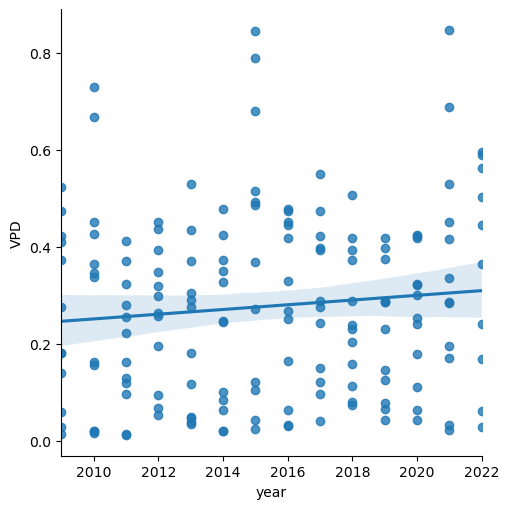

In [125]:
sns.lmplot(x= "year", y = "VPD", data = df8)

<AxesSubplot:>

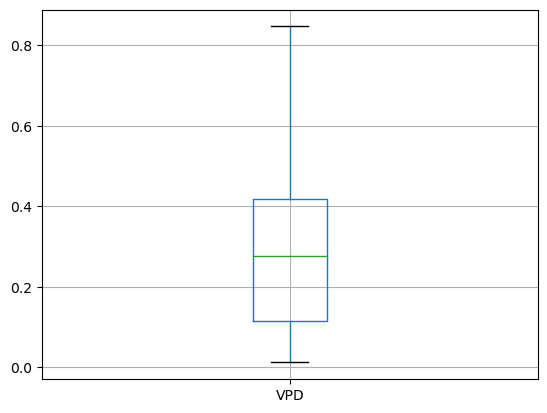

In [126]:
df8.boxplot(column = ["VPD"])

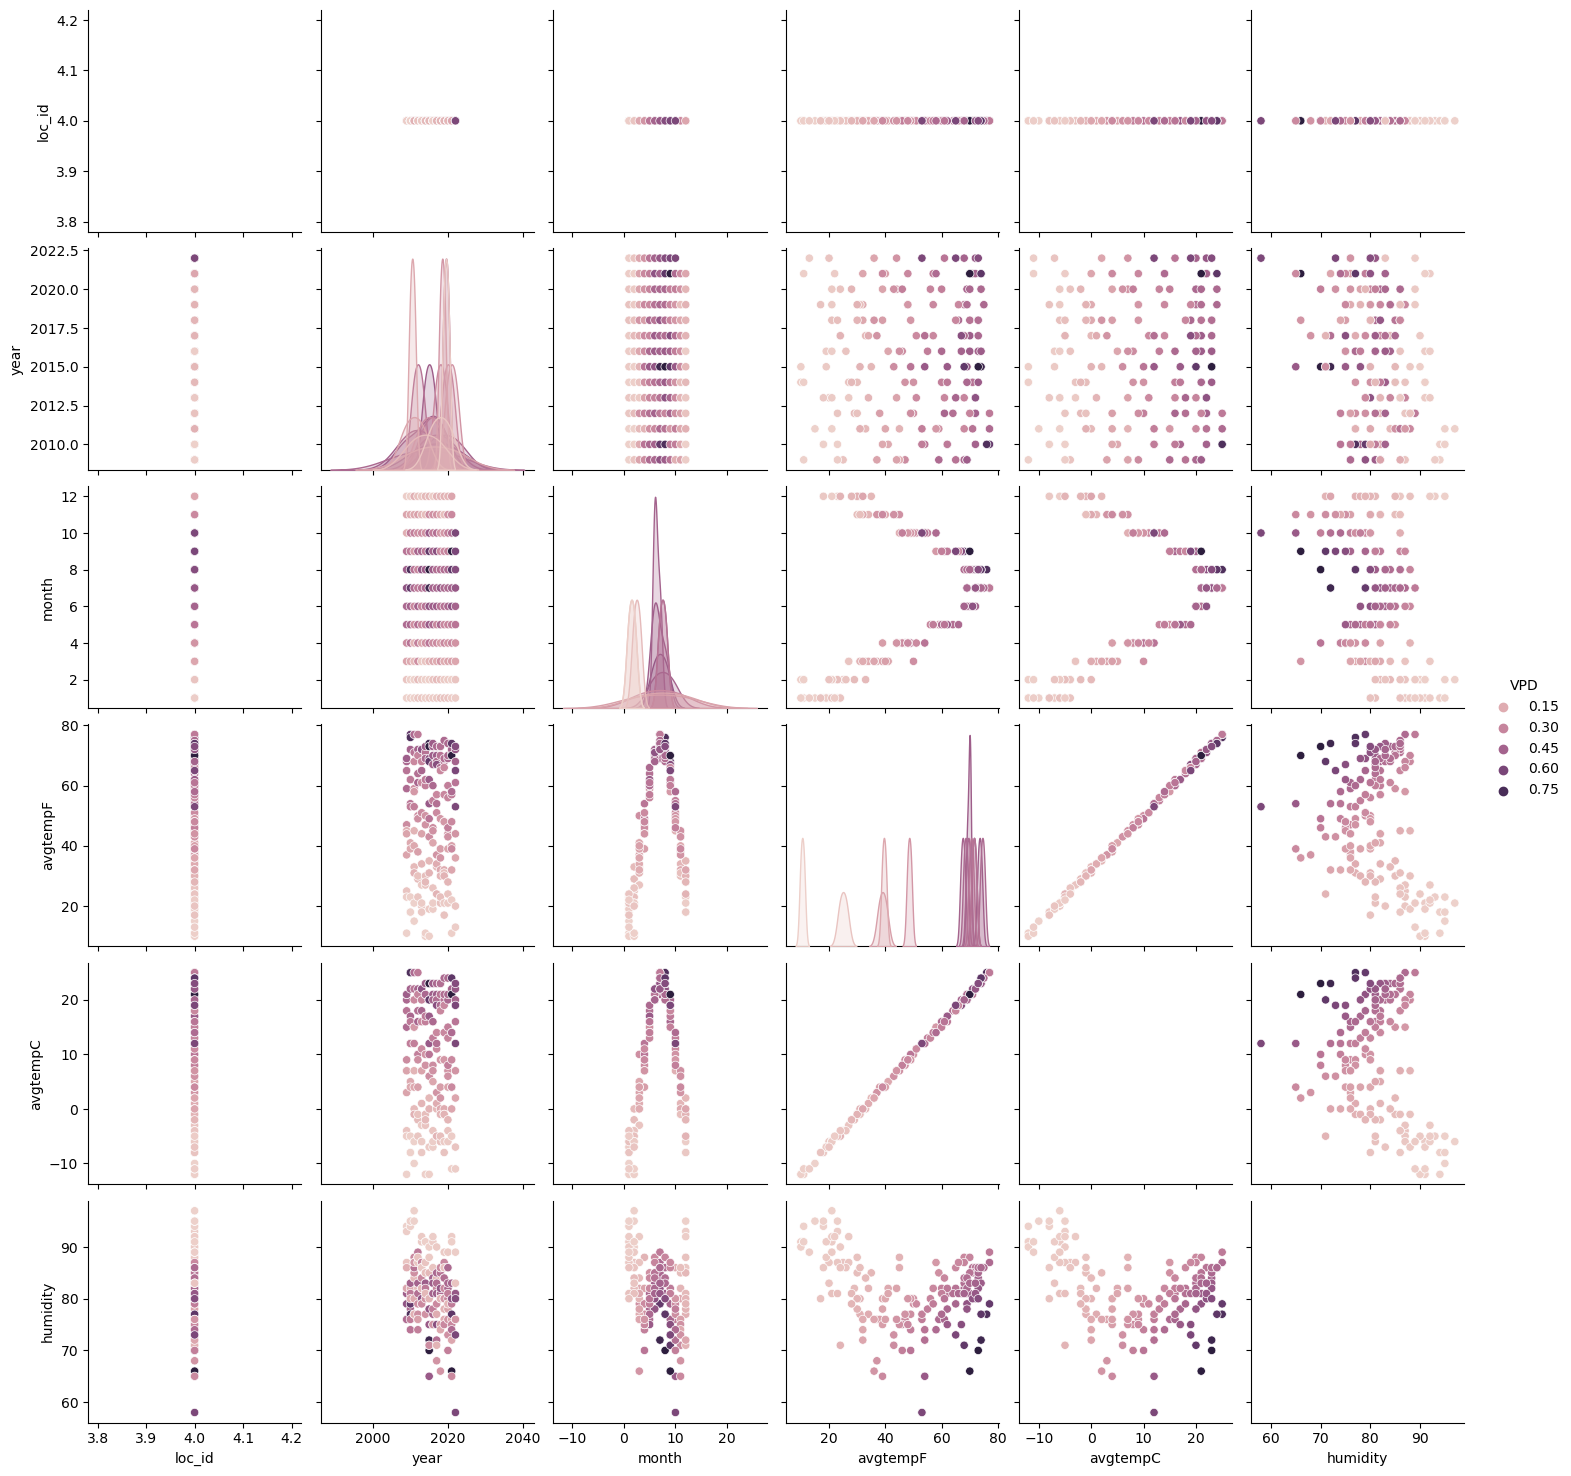

In [127]:
sns.pairplot(data = df8, hue = 'VPD')
plt.show()

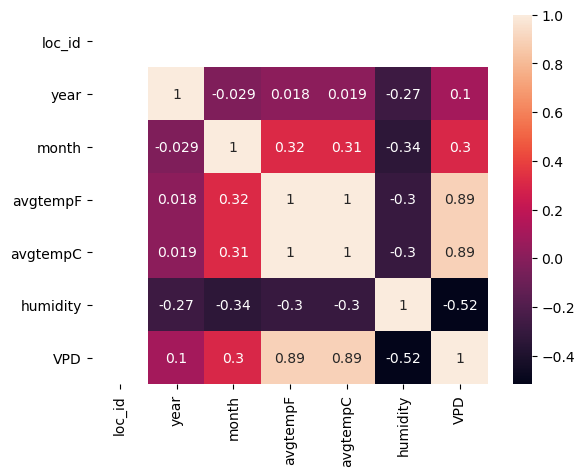

In [128]:
sns.heatmap(df8.corr(), annot = True)
plt.show()

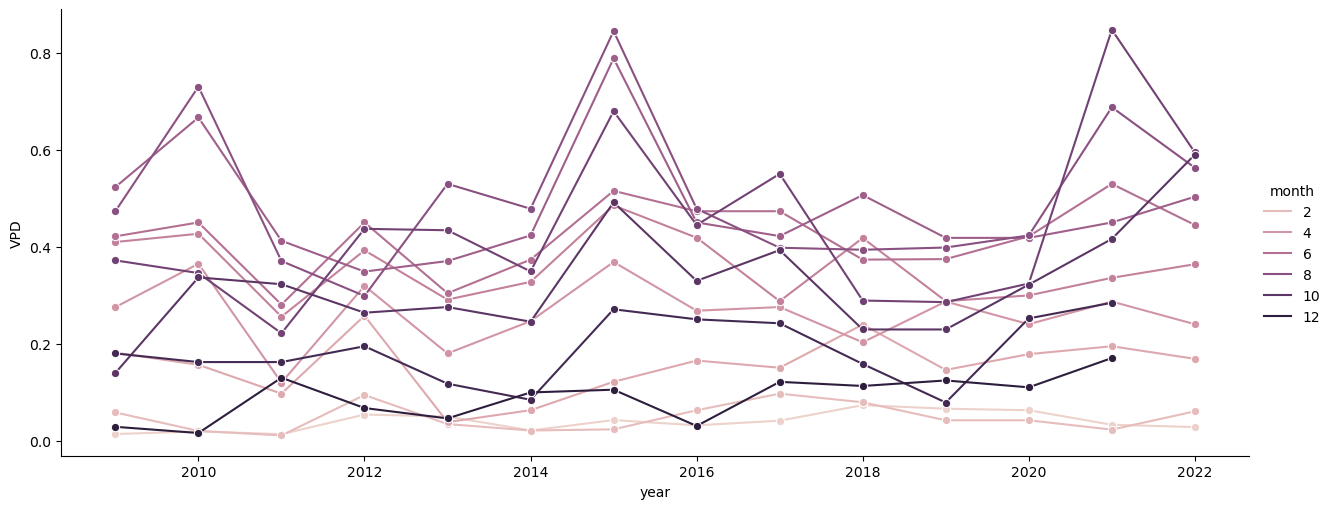

In [129]:
sns.relplot(kind='line', data=df8, x='year', y='VPD', hue='month', aspect=2.5, marker='o')

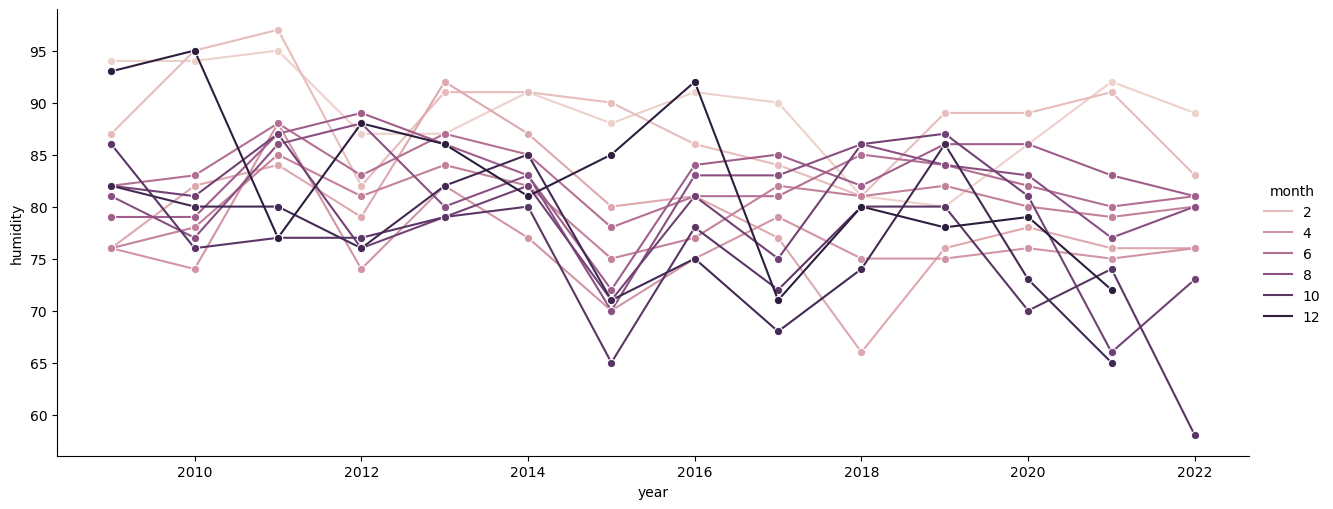

In [130]:
sns.relplot(kind='line', data=df8, x='year', y='humidity', hue='month', aspect=2.5, marker='o')

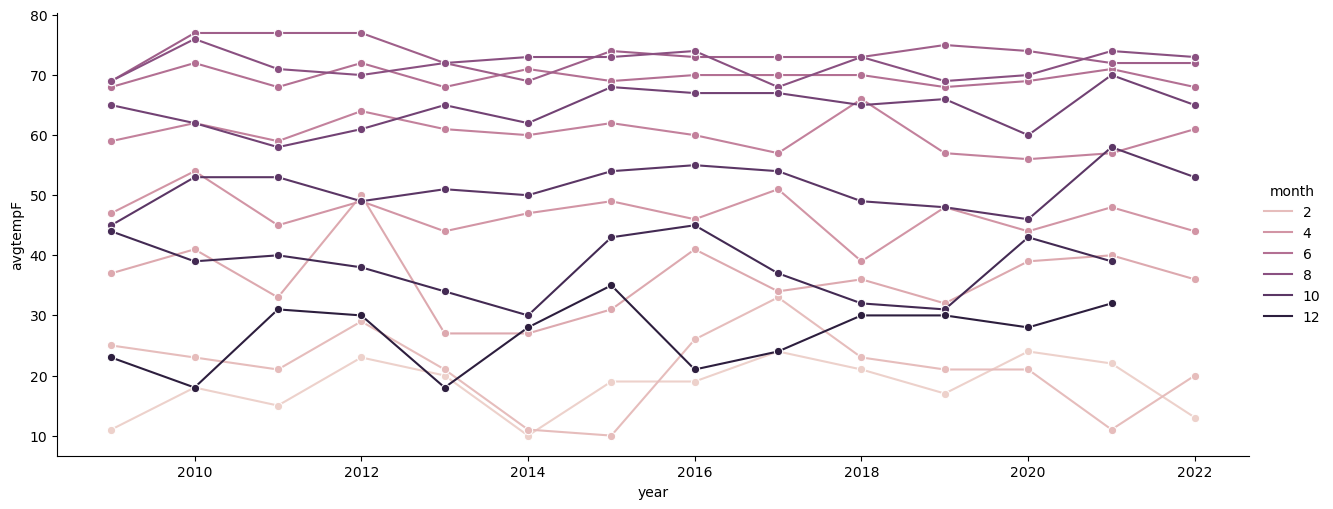

In [131]:
sns.relplot(kind='line', data=df8, x='year', y='avgtempF', hue='month', aspect=2.5, marker='o')

In [132]:
Mean_VPD_March_WayersCave = df4[(df4["month"] == 3) & (df4["loc_id"] == 5)]["VPD"].mean()
Mean_VPD_March_WayersCave

0.2525887450537373

In [133]:
Mean_VPD_April_WayersCave = df4[(df4["month"] == 4) & (df4["loc_id"] == 5)]["VPD"].mean()
Mean_VPD_April_WayersCave

0.3973247277932726

In [134]:
Mean_Humidity_March_WayersCave = df4[(df4["month"] == 3) & (df4["loc_id"] == 5)]["humidity"].mean()
Mean_Humidity_March_WayersCave

75.5

In [135]:
Mean_Humidity_April_WayersCave = df4[(df4["month"] == 4) & (df4["loc_id"] == 5)]["humidity"].mean()
Mean_Humidity_April_WayersCave

73.92857142857143

In [136]:
Mean_Temperature_March_WayersCave = df4[(df4["month"] == 3) & (df4["loc_id"] == 5)]["avgtempF"].mean()
Mean_Temperature_March_WayersCave

44.857142857142854

In [137]:
Mean_Temperature_April_WayersCave = df4[(df4["month"] == 4) & (df4["loc_id"] == 5)]["avgtempF"].mean()
Mean_Temperature_April_WayersCave

55.785714285714285

In [138]:
Describe_WayersCave = df4[(df4["loc_id"] == 5)].describe()
Describe_WayersCave

,loc_id,year,month,avgtempF,avgtempC,humidity,VPD
count,166.0,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000
mean,5.0,2015.421687,6.439759,56.469880,13.602410,75.144578,0.452532
std,0.0,4.003394,3.438549,16.079603,8.961114,4.822001,0.276110
min,5.0,2009.000000,1.000000,27.000000,-3.000000,63.000000,0.042177
25%,5.0,2012.000000,3.250000,41.000000,5.000000,72.000000,0.226953
50%,5.0,2015.000000,6.000000,56.500000,13.500000,75.000000,0.373370
75%,5.0,2019.000000,9.000000,72.000000,22.000000,78.000000,0.609037
max,5.0,2022.000000,12.000000,82.000000,28.000000,92.000000,1.287095


In [139]:
df9 = df4.loc[df4['loc_id'] == 5]
#pd.set_option('display.max_rows', df9.shape[0]+1)
#print(df9)

In [140]:
Avg_VPD_2009 = df9[(df9["year"] == 2009)]["VPD"].mean()
Avg_VPD_2009

0.41409329659922967

In [141]:
Avg_VPD_2010 = df9[(df9["year"] == 2010)]["VPD"].mean()
Avg_VPD_2010

0.5484626966208538

In [142]:
Avg_VPD_2011 = df9[(df9["year"] == 2011)]["VPD"].mean()
Avg_VPD_2011

0.5003630965839966

In [143]:
Avg_VPD_2012 = df9[(df9["year"] == 2012)]["VPD"].mean()
Avg_VPD_2012

0.4560416839414985

In [144]:
Avg_VPD_2013 = df9[(df9["year"] == 2013)]["VPD"].mean()
Avg_VPD_2013

0.36853183990631794

In [145]:
Avg_VPD_2014 = df9[(df9["year"] == 2014)]["VPD"].mean()
Avg_VPD_2014

0.3919535928320026

In [146]:
Avg_VPD_2015 = df9[(df9["year"] == 2015)]["VPD"].mean()
Avg_VPD_2015

0.39076828560075816

In [147]:
Avg_VPD_2016 = df9[(df9["year"] == 2016)]["VPD"].mean()
Avg_VPD_2016

0.43096133632346584

In [148]:
Avg_VPD_2017 = df9[(df9["year"] == 2017)]["VPD"].mean()
Avg_VPD_2017

0.4554143554400866

In [149]:
Avg_VPD_2018 = df9[(df9["year"] == 2018)]["VPD"].mean()
Avg_VPD_2018

0.3863730238490625

In [150]:
Avg_VPD_2019 = df9[(df9["year"] == 2019)]["VPD"].mean()
Avg_VPD_2019

0.4804960563823533

In [151]:
Avg_VPD_2020 = df9[(df9["year"] == 2020)]["VPD"].mean()
Avg_VPD_2020

0.41569105853898985

In [152]:
Avg_VPD_2021 = df9[(df9["year"] == 2021)]["VPD"].mean()
Avg_VPD_2021

0.5405874569106691

In [153]:
Avg_VPD_2022 = df9[(df9["year"] == 2022)]["VPD"].mean()
Avg_VPD_2022

0.5763379794396416

In [154]:
data99 = [[2009, 0.41409329659922967], [2010,0.5484626966208538 ], [2011,0.5003630965839966 ],[2012,0.4560416839414985],[2013,0.36853183990631794],[2014,0.3919535928320026],[2015,0.39076828560075816],[2016,0.43096133632346584],[2017,0.4554143554400866],[2018,0.3863730238490625],[2019,0.4804960563823533],[2020,0.41569105853898985],[2021,0.5405874569106691],[2022,0.5763379794396416]]
df99 = pd.DataFrame(data99, columns=['year', 'Mean_VPD'])
df99

,year,Mean_VPD
0,2009,0.414093
1,2010,0.548463
2,2011,0.500363
3,2012,0.456042
4,2013,0.368532
5,2014,0.391954
6,2015,0.390768
7,2016,0.430961
8,2017,0.455414
9,2018,0.386373


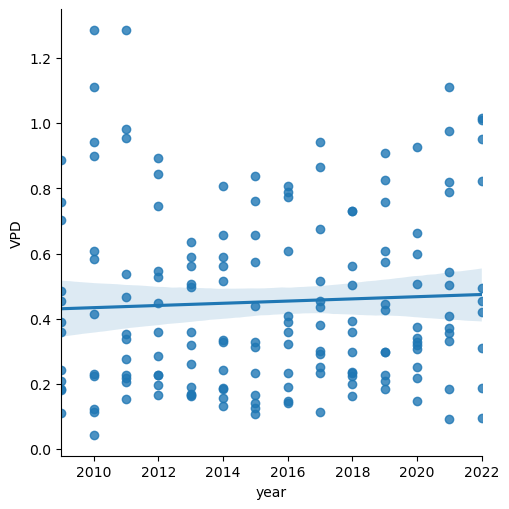

In [155]:
sns.lmplot(x= "year", y = "VPD", data = df9)

<AxesSubplot:>

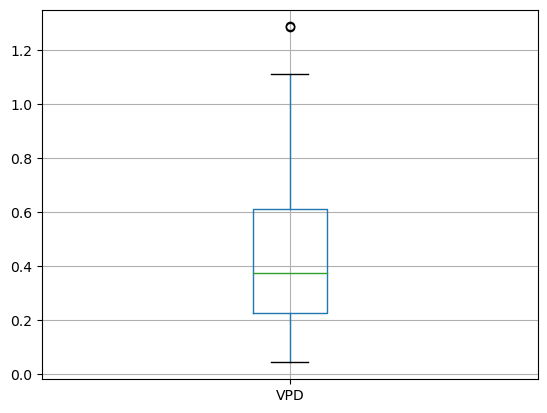

In [156]:
df9.boxplot(column = ["VPD"])

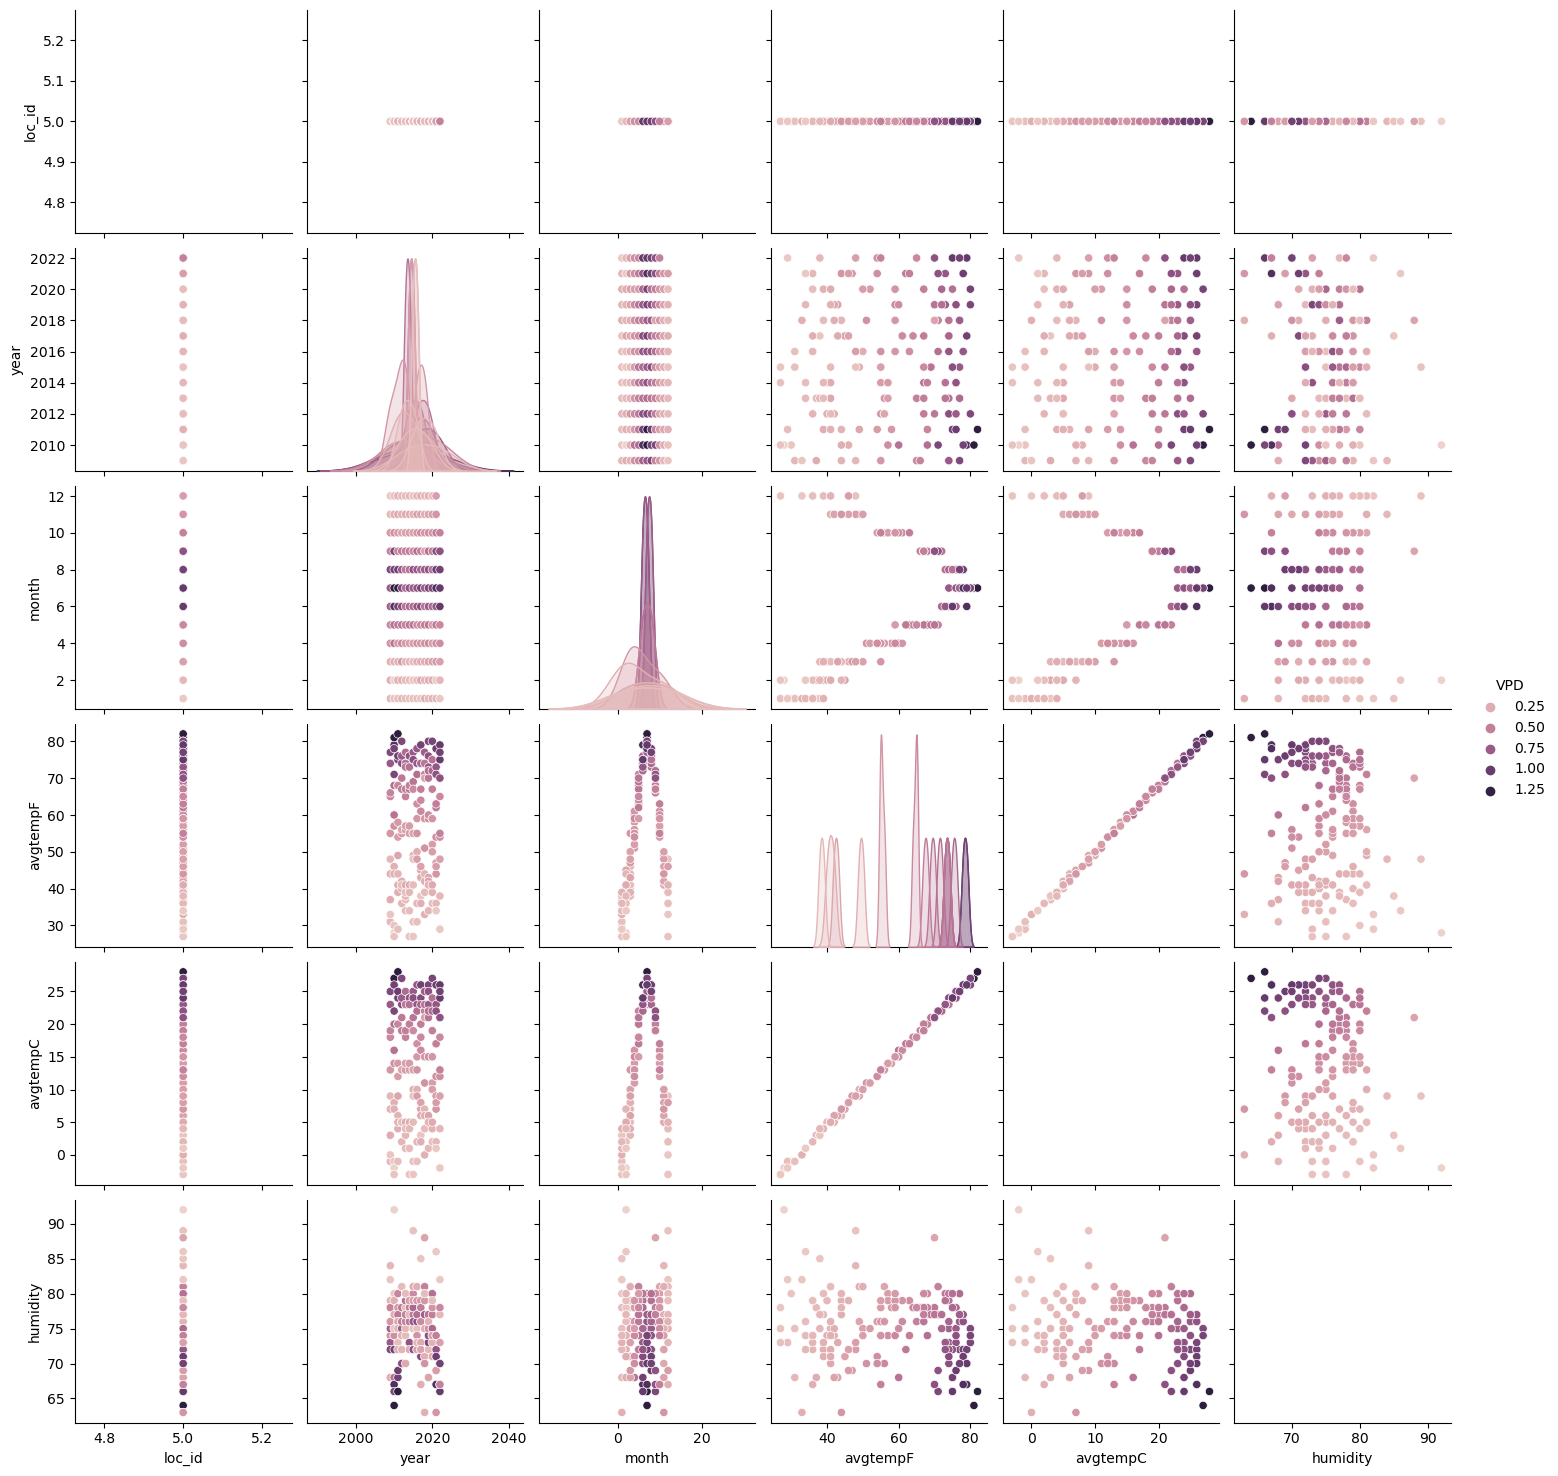

In [157]:
sns.pairplot(data = df9, hue = 'VPD')
plt.show()

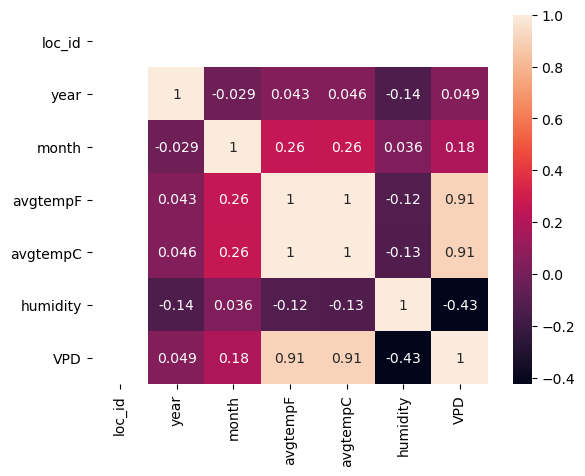

In [158]:
sns.heatmap(df9.corr(), annot = True)
plt.show()

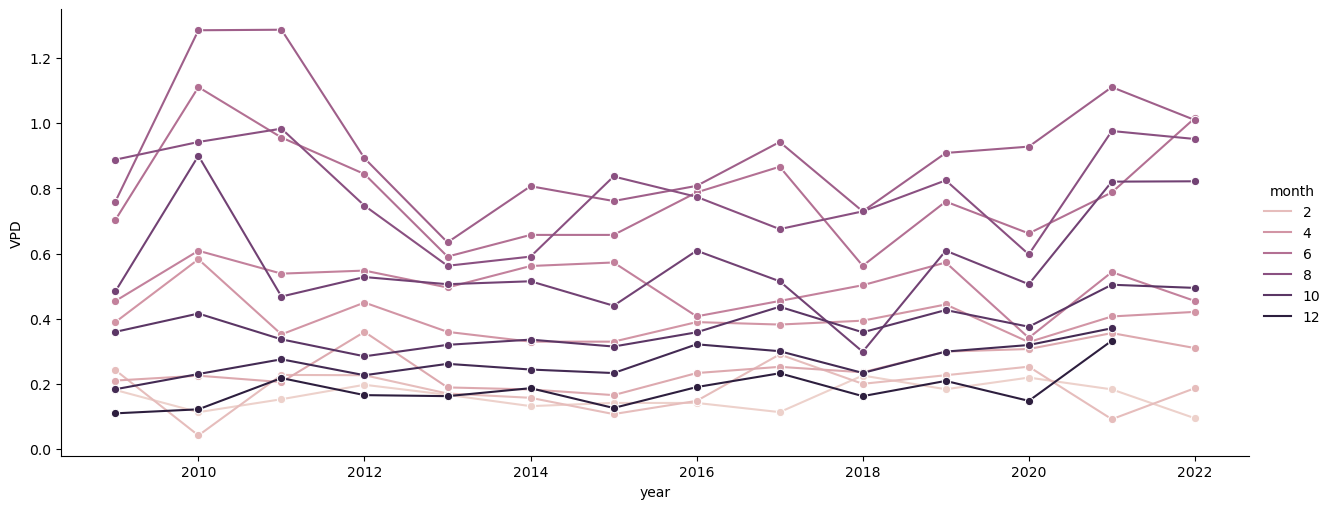

In [159]:
sns.relplot(kind='line', data=df9, x='year', y='VPD', hue='month', aspect=2.5, marker='o')

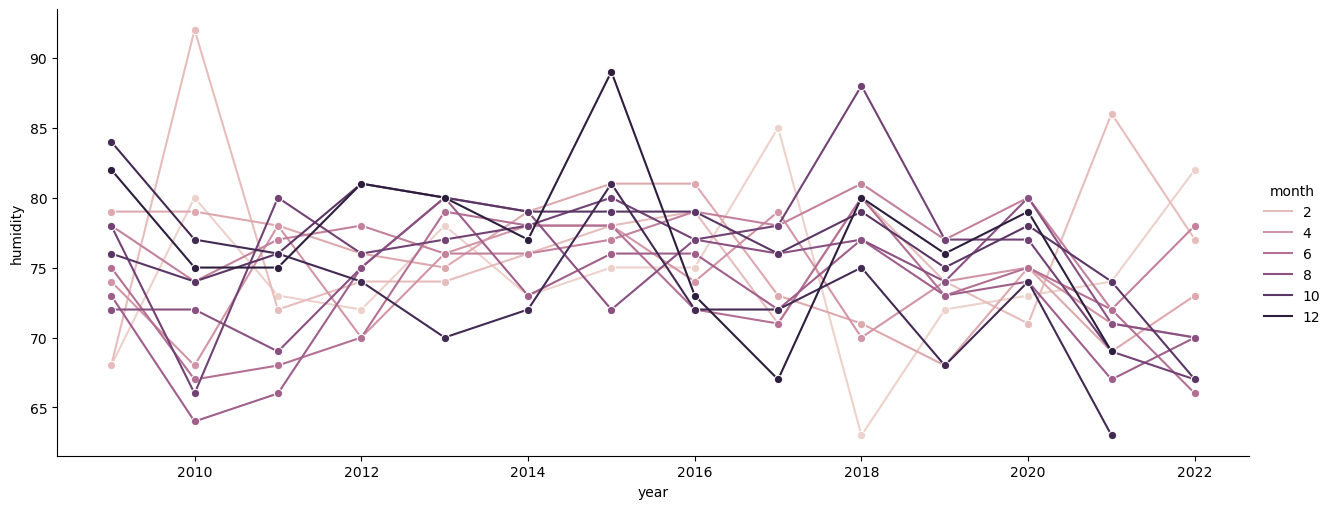

In [160]:
sns.relplot(kind='line', data=df9, x='year', y='humidity', hue='month', aspect=2.5, marker='o')

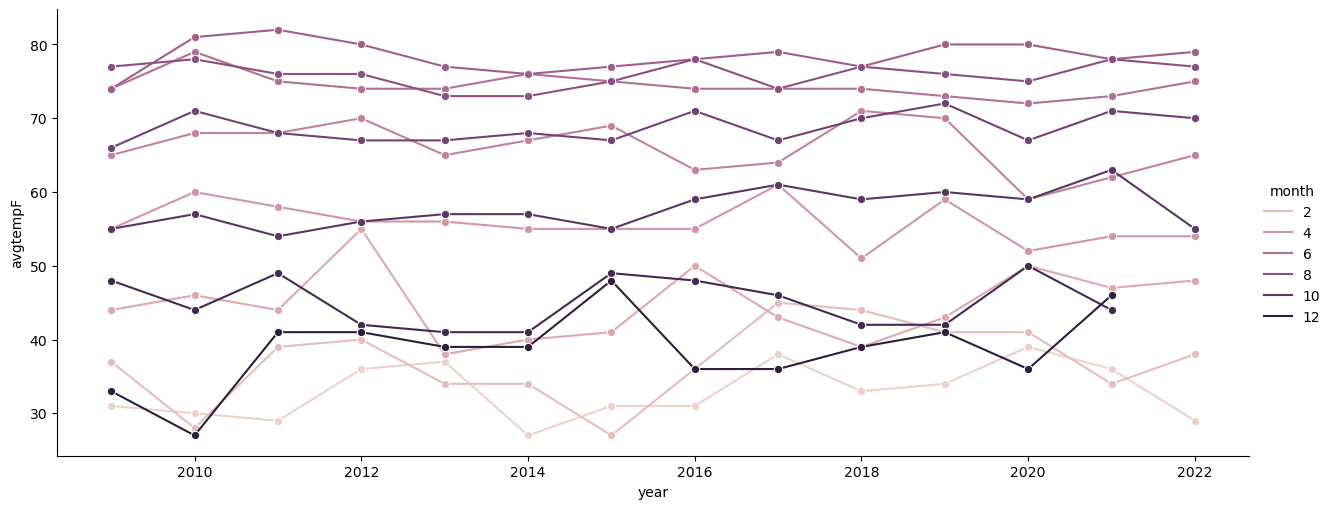

In [161]:
sns.relplot(kind='line', data=df9, x='year', y='avgtempF', hue='month', aspect=2.5, marker='o')

In [162]:
Mean_VPD_March_Philadelphia = df4[(df4["month"] == 3) & (df4["loc_id"] == 6)]["VPD"].mean()
Mean_VPD_March_Philadelphia

0.3088776425502441

In [163]:
Mean_VPD_April_Philadelphia = df4[(df4["month"] == 4) & (df4["loc_id"] == 6)]["VPD"].mean()
Mean_VPD_April_Philadelphia

0.4770344965198893

In [164]:
Mean_Humidity_March_Philadelphia = df4[(df4["month"] == 3) & (df4["loc_id"] == 6)]["humidity"].mean()
Mean_Humidity_March_Philadelphia

70.28571428571429

In [165]:
Mean_Humidity_April_Philadelphia = df4[(df4["month"] == 4) & (df4["loc_id"] == 6)]["humidity"].mean()
Mean_Humidity_April_Philadelphia

68.71428571428571

In [166]:
Mean_Temperature_March_Philadelphia = df4[(df4["month"] == 3) & (df4["loc_id"] == 6)]["avgtempF"].mean()
Mean_Temperature_March_Philadelphia

44.785714285714285

In [167]:
Mean_Temperature_April_Philadelphia = df4[(df4["month"] == 4) & (df4["loc_id"] == 6)]["avgtempF"].mean()
Mean_Temperature_April_Philadelphia

55.857142857142854

In [168]:
Describe_Philadelphia = df4[(df4["loc_id"] == 6)].describe()
Describe_Philadelphia

,loc_id,year,month,avgtempF,avgtempC,humidity,VPD
count,166.0,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000
mean,6.0,2015.421687,6.439759,58.337349,14.596386,71.626506,0.567579
std,0.0,4.003394,3.438549,17.075076,9.482986,9.031542,0.410996
min,6.0,2009.000000,1.000000,24.000000,-4.000000,53.000000,0.039735
25%,6.0,2012.000000,3.250000,43.000000,6.000000,63.000000,0.252389
50%,6.0,2015.000000,6.000000,59.000000,15.000000,73.000000,0.432647
75%,6.0,2019.000000,9.000000,74.000000,23.750000,79.000000,0.746419
max,6.0,2022.000000,12.000000,87.000000,30.000000,93.000000,1.869593


In [169]:
df10 = df4.loc[df4['loc_id'] == 6]
#pd.set_option('display.max_rows', df10.shape[0]+1)
#print(df10)

In [170]:
Avg_VPD_2009 = df10[(df10["year"] == 2009)]["VPD"].mean()
Avg_VPD_2009

0.3394936938067102

In [171]:
Avg_VPD_2010 = df10[(df10["year"] == 2010)]["VPD"].mean()
Avg_VPD_2010

0.46335952283148923

In [172]:
Avg_VPD_2011 = df10[(df10["year"] == 2011)]["VPD"].mean()
Avg_VPD_2011

0.3383220737681987

In [173]:
Avg_VPD_2012 = df10[(df10["year"] == 2012)]["VPD"].mean()
Avg_VPD_2012

0.3859560724573075

In [174]:
Avg_VPD_2013 = df10[(df10["year"] == 2013)]["VPD"].mean()
Avg_VPD_2013

0.3858034933995973

In [175]:
Avg_VPD_2014 = df10[(df10["year"] == 2014)]["VPD"].mean()
Avg_VPD_2014

0.37547289639490583

In [176]:
Avg_VPD_2015 = df10[(df10["year"] == 2015)]["VPD"].mean()
Avg_VPD_2015

0.5583531691730176

In [177]:
Avg_VPD_2016 = df10[(df10["year"] == 2016)]["VPD"].mean()
Avg_VPD_2016

0.49965001549602434

In [178]:
Avg_VPD_2017 = df10[(df10["year"] == 2017)]["VPD"].mean()
Avg_VPD_2017

0.6428145614006673

In [179]:
Avg_VPD_2018 = df10[(df10["year"] == 2018)]["VPD"].mean()
Avg_VPD_2018

0.7961516091983927

In [180]:
Avg_VPD_2019 = df10[(df10["year"] == 2019)]["VPD"].mean()
Avg_VPD_2019

0.8644405245007709

In [181]:
Avg_VPD_2020 = df10[(df10["year"] == 2020)]["VPD"].mean()
Avg_VPD_2020

0.8280116474775184

In [182]:
Avg_VPD_2021 = df10[(df10["year"] == 2021)]["VPD"].mean()
Avg_VPD_2021

0.687164030915257

In [183]:
Avg_VPD_2022 = df10[(df10["year"] == 2022)]["VPD"].mean()
Avg_VPD_2022

0.8238125039861739

In [184]:
data100 = [[2009, 0.3394936938067102], [2010,0.46335952283148923 ], [2011,0.3383220737681987 ],[2012,0.3859560724573075],[2013,0.3858034933995973],[2014,0.37547289639490583],[2015,0.5583531691730176],[2016,0.49965001549602434],[2017,0.6428145614006673],[2018,0.7961516091983927],[2019,0.8644405245007709],[2020,0.8280116474775184],[2021,0.687164030915257],[2022,0.8238125039861739]]
df100 = pd.DataFrame(data100, columns=['year', 'Mean_VPD'])
df100

,year,Mean_VPD
0,2009,0.339494
1,2010,0.463360
2,2011,0.338322
3,2012,0.385956
4,2013,0.385803
5,2014,0.375473
6,2015,0.558353
7,2016,0.499650
8,2017,0.642815
9,2018,0.796152


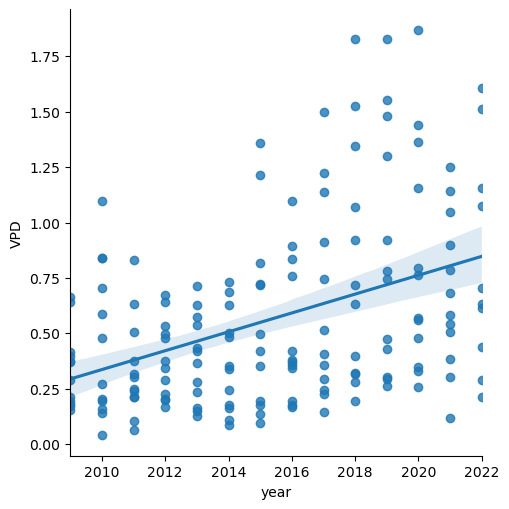

In [185]:
sns.lmplot(x= "year", y = "VPD", data = df10)

<AxesSubplot:>

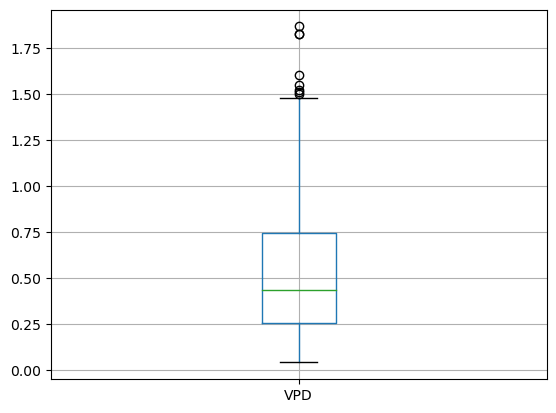

In [186]:
df10.boxplot(column = ["VPD"])

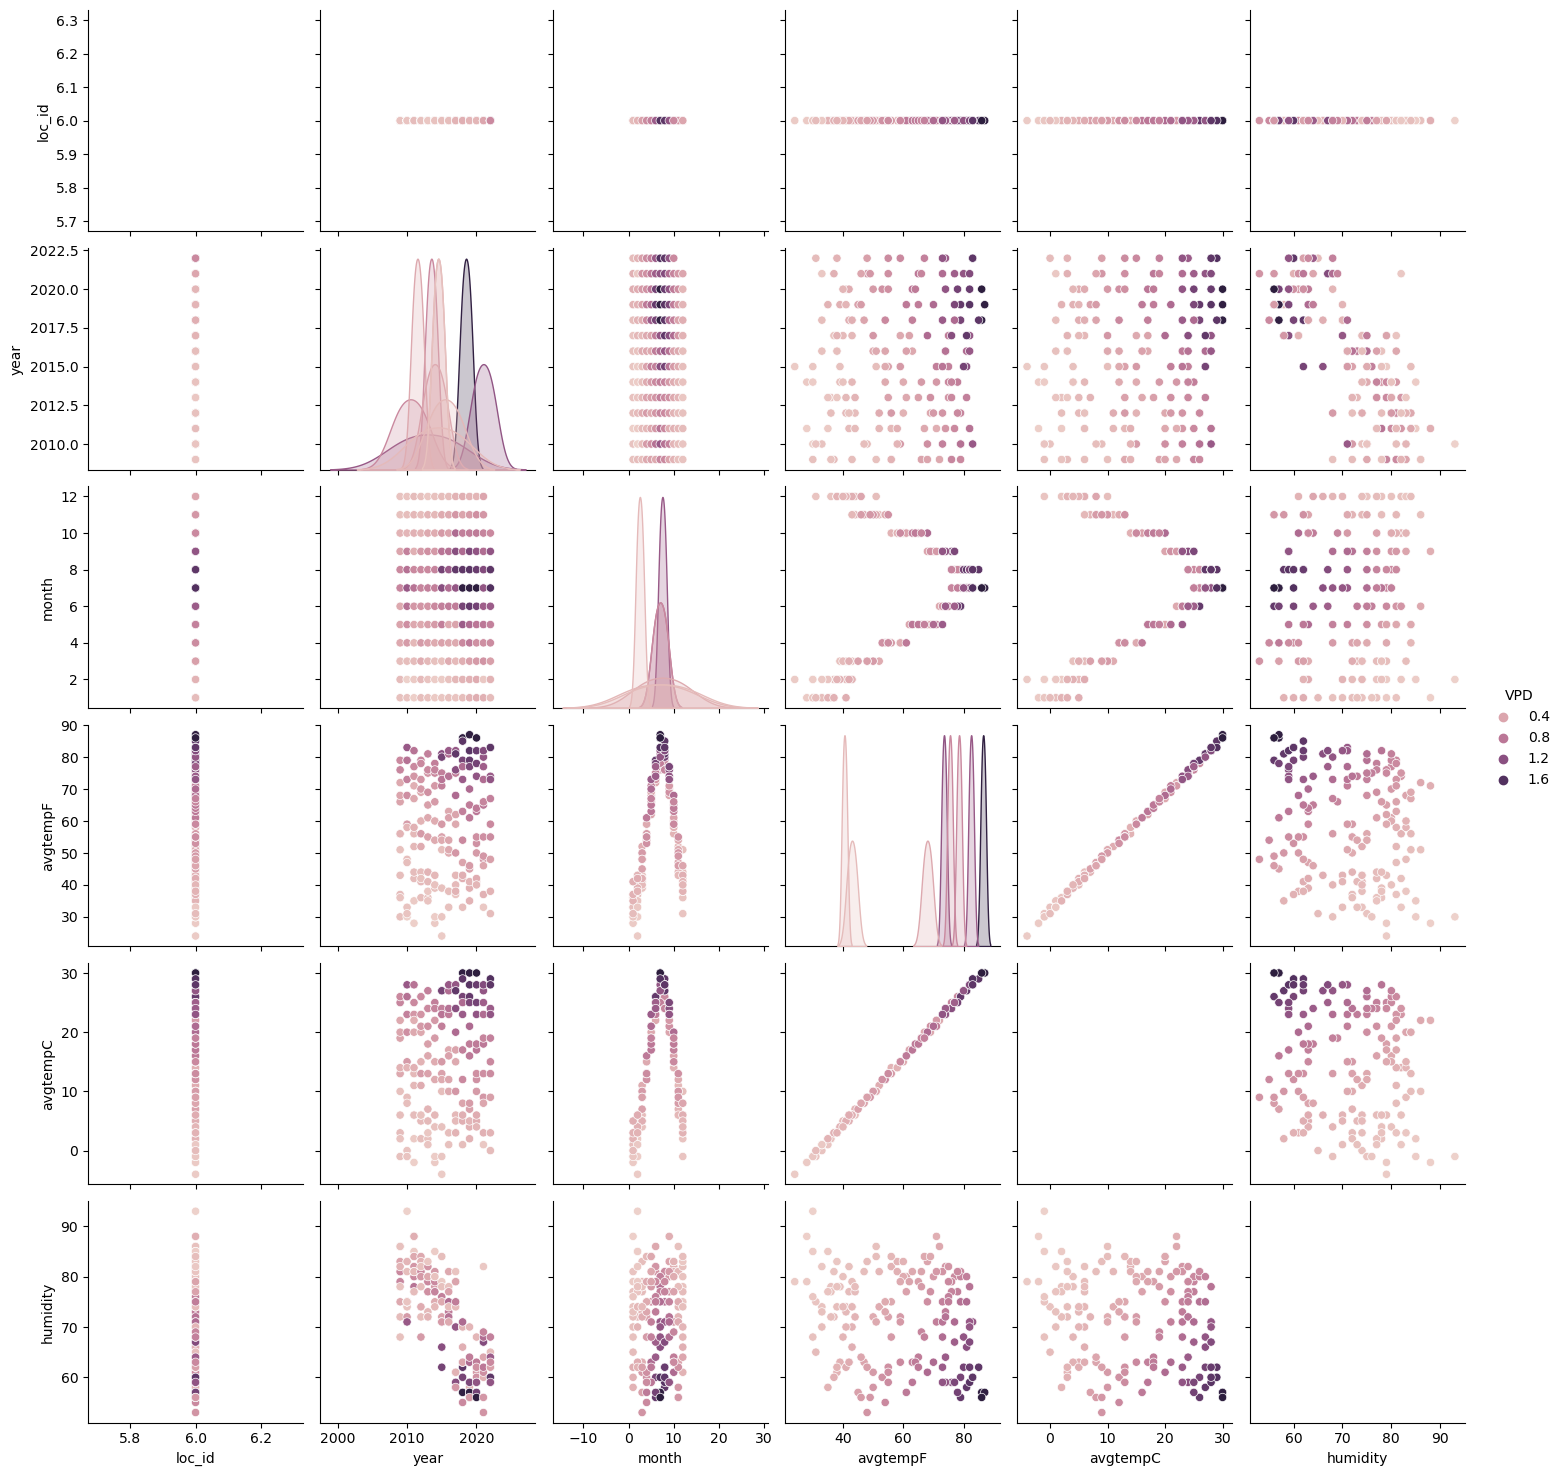

In [187]:
sns.pairplot(data = df10, hue = 'VPD')
plt.show()

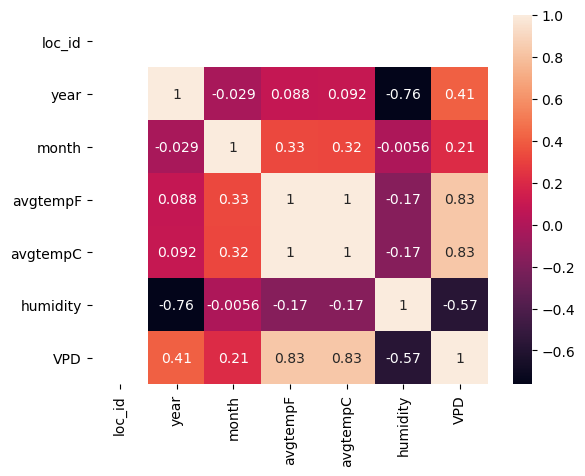

In [188]:
sns.heatmap(df10.corr(), annot = True)
plt.show()

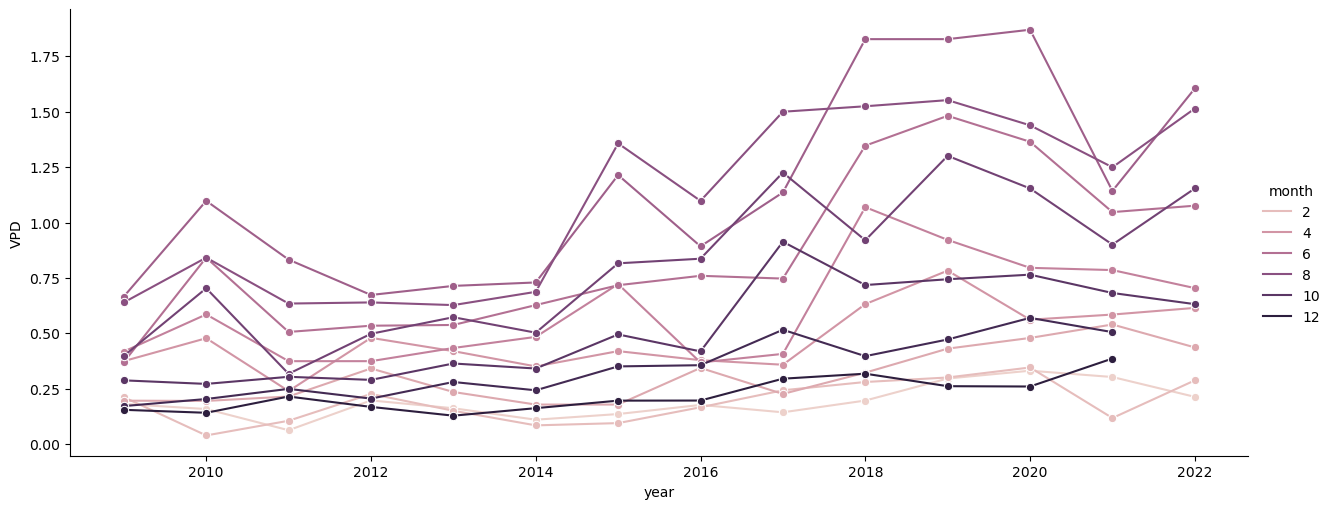

In [189]:
sns.relplot(kind='line', data=df10, x='year', y='VPD', hue='month', aspect=2.5, marker='o')

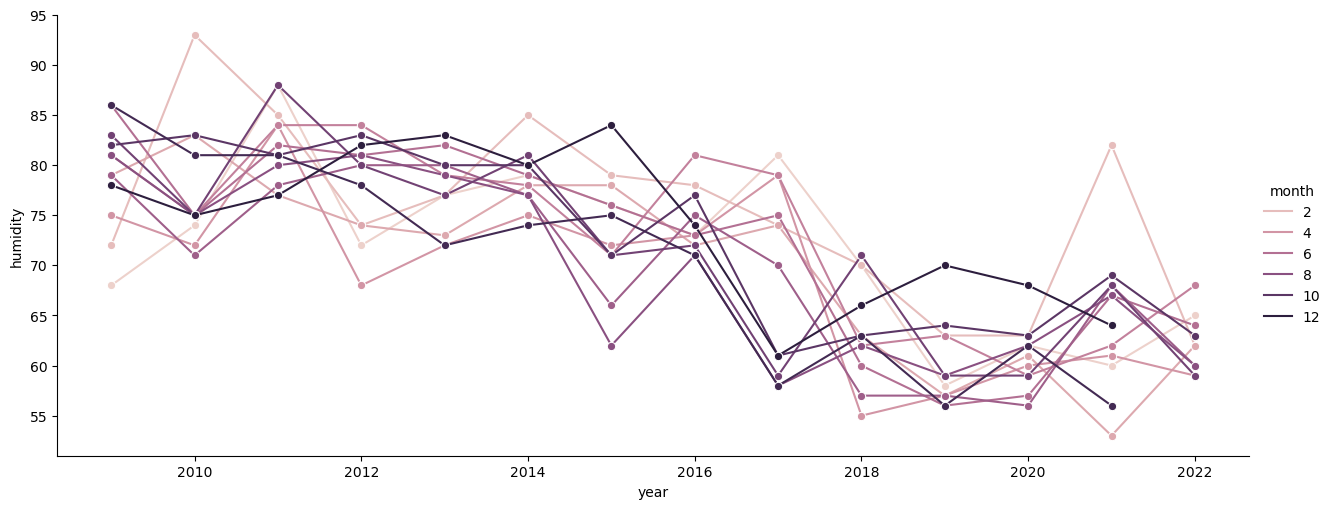

In [190]:
sns.relplot(kind='line', data=df10, x='year', y='humidity', hue='month', aspect=2.5, marker='o')

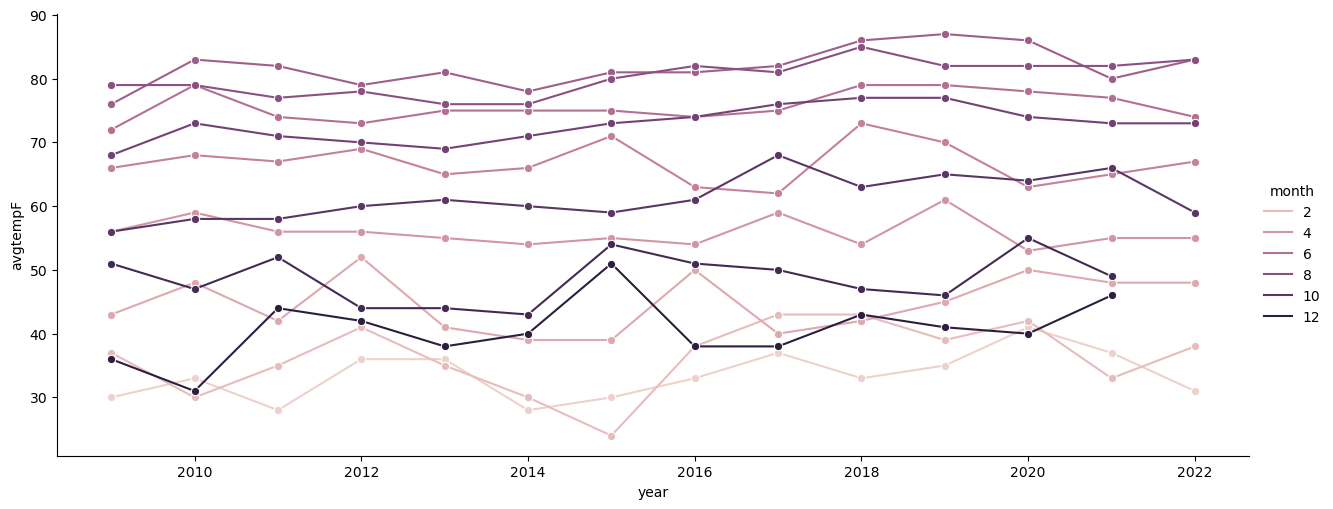

In [191]:
sns.relplot(kind='line', data=df10, x='year', y='avgtempF', hue='month', aspect=2.5, marker='o')

In [192]:
import pandas as pd
import statsmodels.api as sm

In [193]:
df5.head()

,loc_id,year,month,avgtempF,avgtempC,humidity,VPD
0,1,2009,1,55,13,66,0.509935
1,1,2009,2,54,12,80,0.280878
2,1,2009,3,57,14,76,0.384207
3,1,2009,4,61,16,66,0.619143
4,1,2009,5,68,20,68,0.749439


In [194]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [195]:
X7 = df5[['avgtempF','humidity']]
y7 = df5['VPD']

In [196]:
X7_train,X7_test,y7_train,y7_test=train_test_split(X7,y7,test_size=0.2,random_state=0)

In [197]:
#formula = 'y ~ x1 + x2 '

In [198]:
regressor7 = LinearRegression(fit_intercept=False)
regressor7.fit(X7_train, y7_train)

LinearRegression(fit_intercept=False)

In [199]:
#sm.add_constant(X5)

In [200]:
model7 = sm.OLS(y7_train,X7_train).fit()

In [201]:
predictions7 = model7.predict(X7_test)

In [202]:
X7_test

,avgtempF,humidity
163,75,60
134,56,65
93,66,71
55,70,75
149,72,61
54,71,69
7,76,62
5,70,68
135,62,66
61,56,79


In [203]:
predictions7

163    1.154432
134    0.519686
93     0.707501
55     0.755514
149    1.050642
54     0.886133
7      1.149490
5      0.874130
135    0.676432
61     0.282456
116    1.159373
139    1.309057
100    0.758336
98     0.499920
51     0.642542
141    1.311879
147    0.761157
126    1.125483
45     0.707501
95     0.398951
125    1.256102
33     0.787284
56     0.806349
122    0.686315
26     0.156779
153    0.881893
106    0.785164
8      1.212329
73     0.630539
37     0.326229
44     0.828236
96     0.217497
152    1.261044
60     0.650305
dtype: float64

In [204]:
print_model7 = model7.summary()
print_model7

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                    VPD   R-squared (uncentered):                   0.993
Model:                            OLS   Adj. R-squared (uncentered):              0.993
Method:                 Least Squares   F-statistic:                              9738.
Date:                Tue, 24 Sep 2024   Prob (F-statistic):                   2.52e-142
Time:                        18:33:17   Log-Likelihood:                          174.95
No. Observations:                 132   AIC:                                     -345.9
Df Residuals:                     130   BIC:                                     -340.1
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
avgtempF       0.0289      0.000     68.054      0.000       0.028       0.030
humidity      -0.0169      0.000    -41.450      0.000      -0.018      -0.016
==============================================================================
Omnibus:                        7.395   Durbin-Watson:                   2.226
Prob(Omnibus):                  0.025   Jarque-Bera (JB):                7.031
Skew:                           0.536   Prob(JB):                       0.0297
Kurtosis:                       3.361   Cond. No.                         9.60
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [205]:
X7_train.shape

(132, 2)

In [206]:
y7_train.shape

(132,)

In [207]:
predictions7.shape

(34,)

In [208]:
X7_test.shape

(34, 2)

In [209]:
y7_test.shape

(34,)

In [210]:
X7.head()

,avgtempF,humidity
0,55,66
1,54,80
2,57,76
3,61,66
4,68,68


In [211]:
X7_train.head()

,avgtempF,humidity
107,60,44
24,54,77
150,75,58
151,76,57
19,70,71


In [212]:
X7_test.head()

,avgtempF,humidity
163,75,60
134,56,65
93,66,71
55,70,75
149,72,61


In [213]:
regressor7.intercept_

0.0

In [214]:
regressor7.coef_

array([ 0.02894844, -0.01694502])

In [215]:
print('Beta: ', regressor7.coef_)

Beta:  [ 0.02894844 -0.01694502]


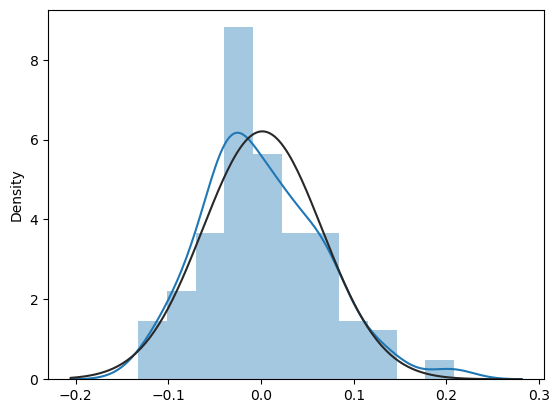

In [216]:
from scipy import stats
sns.distplot(model7.resid, fit=stats.norm);

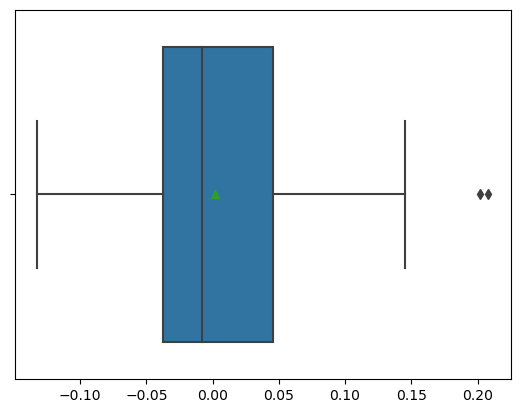

In [217]:
sns.boxplot(model7.resid, showmeans=True);

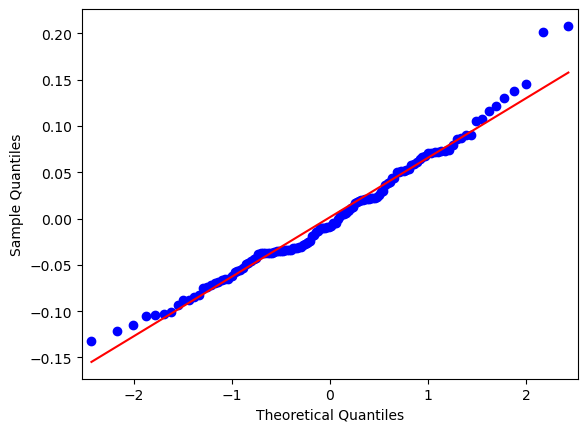

In [218]:
sm.qqplot(model7.resid, line='s');

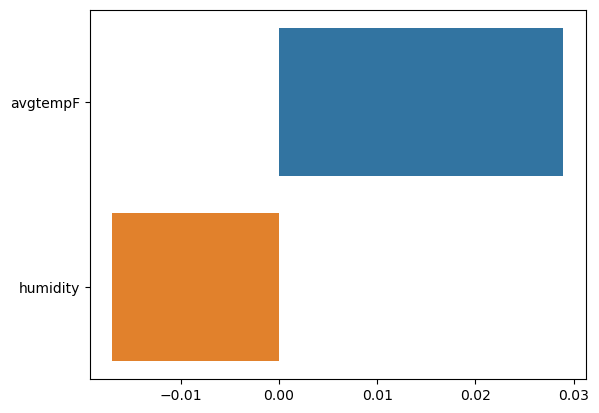

In [219]:
coeff = model7.params
coeff = coeff.iloc[(coeff.abs()*-1.0).argsort()]
sns.barplot(x=coeff.values, y=coeff.index, orient='h');

In [220]:
X72 = df6[['avgtempF','humidity']]
y72 = df6['VPD']

In [221]:
X72_train,X72_test,y72_train,y72_test=train_test_split(X72,y72,test_size=0.2,random_state=0)

In [222]:
model72 = sm.OLS(y72_train,X72_train).fit()

In [223]:
predictions72 = model72.predict(X72_test)

In [224]:
print_model72 = model72.summary()
print_model72

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                    VPD   R-squared (uncentered):                   0.961
Model:                            OLS   Adj. R-squared (uncentered):              0.960
Method:                 Least Squares   F-statistic:                              1585.
Date:                Tue, 24 Sep 2024   Prob (F-statistic):                    5.05e-92
Time:                        18:33:49   Log-Likelihood:                          165.29
No. Observations:                 132   AIC:                                     -326.6
Df Residuals:                     130   BIC:                                     -320.8
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
avgtempF       0.0105      0.000     33.490      0.000       0.010       0.011
humidity      -0.0029      0.000    -14.356      0.000      -0.003      -0.002
==============================================================================
Omnibus:                       28.985   Durbin-Watson:                   2.258
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               67.299
Skew:                           0.873   Prob(JB):                     2.43e-15
Kurtosis:                       6.031   Cond. No.                         5.78
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

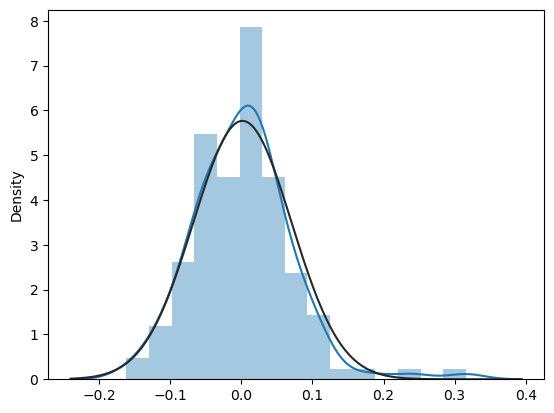

In [225]:
from scipy import stats
sns.distplot(model72.resid, fit=stats.norm);

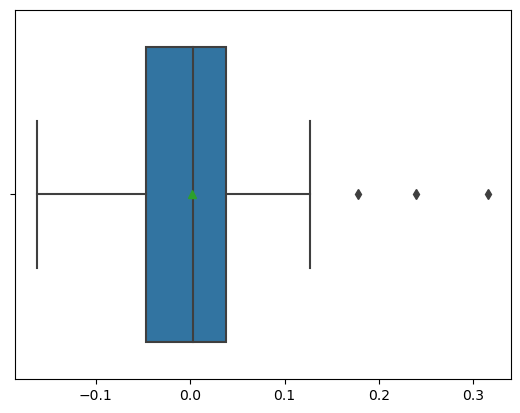

In [226]:
sns.boxplot(model72.resid, showmeans=True);

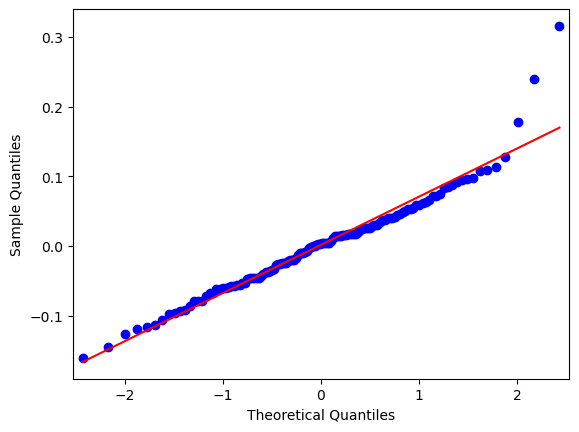

In [227]:
sm.qqplot(model72.resid, line='s');

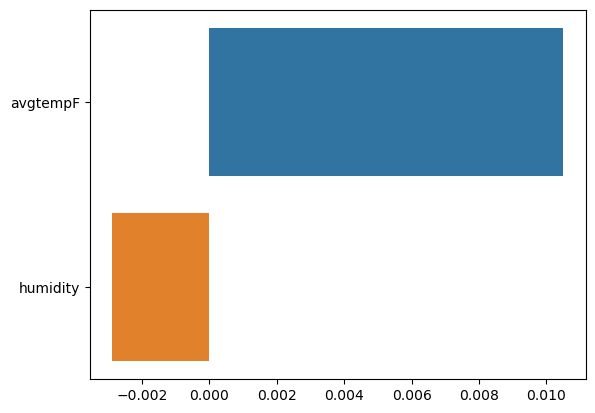

In [228]:
coeff72 = model72.params
coeff72 = coeff72.iloc[(coeff.abs()*-1.0).argsort()]
sns.barplot(x=coeff72.values, y=coeff72.index, orient='h');

In [229]:
X73 = df7[['avgtempF','humidity']]
y73 = df7['VPD']

In [230]:
X73_train,X73_test,y73_train,y73_test=train_test_split(X73,y73,test_size=0.2,random_state=0)

In [231]:
model73 = sm.OLS(y73_train,X73_train).fit()

In [232]:
predictions73 = model73.predict(X73_test)

In [233]:
print_model73 = model73.summary()
print_model73

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                    VPD   R-squared (uncentered):                   0.958
Model:                            OLS   Adj. R-squared (uncentered):              0.957
Method:                 Least Squares   F-statistic:                              1479.
Date:                Tue, 24 Sep 2024   Prob (F-statistic):                    3.75e-90
Time:                        18:34:03   Log-Likelihood:                          169.26
No. Observations:                 132   AIC:                                     -334.5
Df Residuals:                     130   BIC:                                     -328.8
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
avgtempF       0.0101      0.000     36.366      0.000       0.010       0.011
humidity      -0.0022      0.000    -13.936      0.000      -0.003      -0.002
==============================================================================
Omnibus:                       12.956   Durbin-Watson:                   1.874
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               13.813
Skew:                           0.706   Prob(JB):                      0.00100
Kurtosis:                       3.719   Cond. No.                         4.89
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

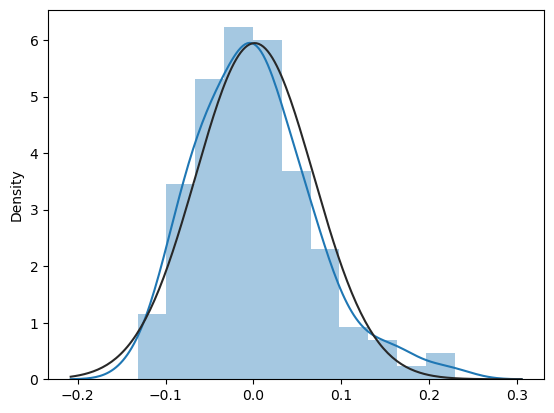

In [234]:
from scipy import stats
sns.distplot(model73.resid, fit=stats.norm);

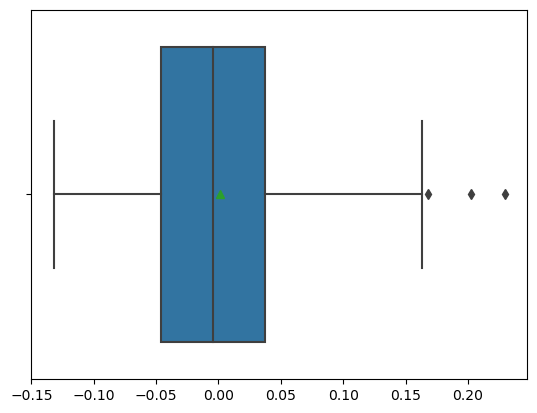

In [235]:
sns.boxplot(model73.resid, showmeans=True);

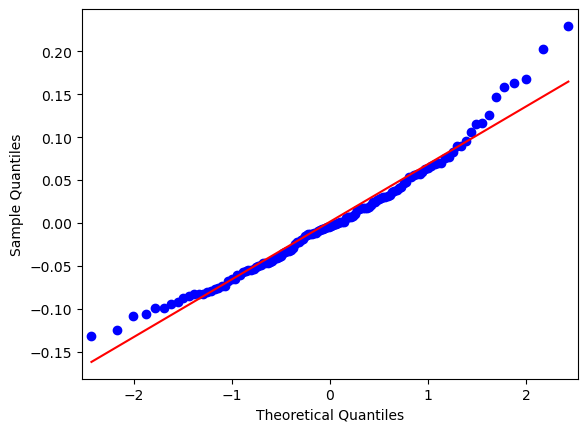

In [236]:
sm.qqplot(model73.resid, line='s');

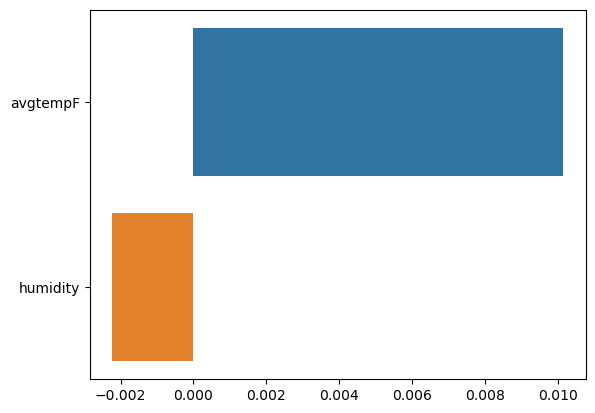

In [237]:
coeff73 = model73.params
coeff73 = coeff73.iloc[(coeff.abs()*-1.0).argsort()]
sns.barplot(x=coeff73.values, y=coeff73.index, orient='h');

In [238]:
X74 = df8[['avgtempF','humidity']]
y74 = df8['VPD']

In [239]:
X74_train,X74_test,y74_train,y74_test=train_test_split(X74,y74,test_size=0.2,random_state=0)

In [240]:
model74 = sm.OLS(y74_train,X74_train).fit()

In [241]:
predictions74 = model74.predict(X74_test)

In [242]:
print_model74 = model74.summary()
print_model74

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                    VPD   R-squared (uncentered):                   0.946
Model:                            OLS   Adj. R-squared (uncentered):              0.945
Method:                 Least Squares   F-statistic:                              1128.
Date:                Tue, 24 Sep 2024   Prob (F-statistic):                    7.34e-83
Time:                        18:34:35   Log-Likelihood:                          151.07
No. Observations:                 132   AIC:                                     -298.1
Df Residuals:                     130   BIC:                                     -292.4
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
avgtempF       0.0087      0.000     27.096      0.000       0.008       0.009
humidity      -0.0018      0.000     -8.933      0.000      -0.002      -0.001
==============================================================================
Omnibus:                       42.583   Durbin-Watson:                   2.084
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              107.354
Skew:                           1.271   Prob(JB):                     4.88e-24
Kurtosis:                       6.613   Cond. No.                         5.26
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

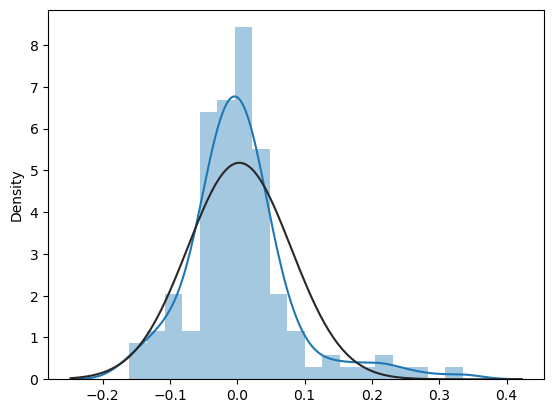

In [243]:
from scipy import stats
sns.distplot(model74.resid, fit=stats.norm);

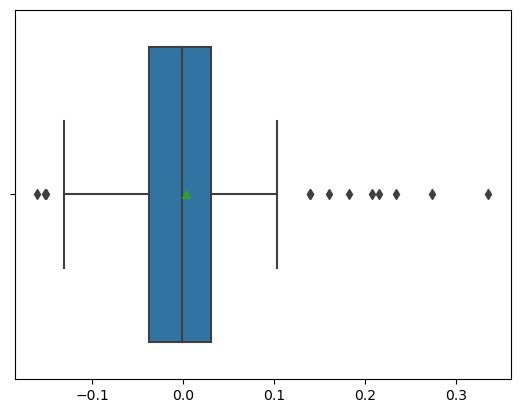

In [244]:
sns.boxplot(model74.resid, showmeans=True);

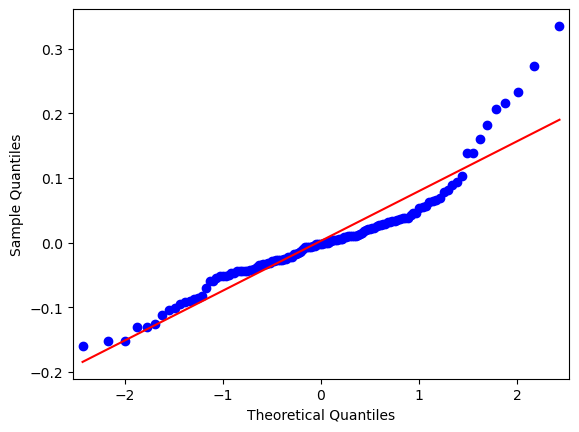

In [245]:
sm.qqplot(model74.resid, line='s');

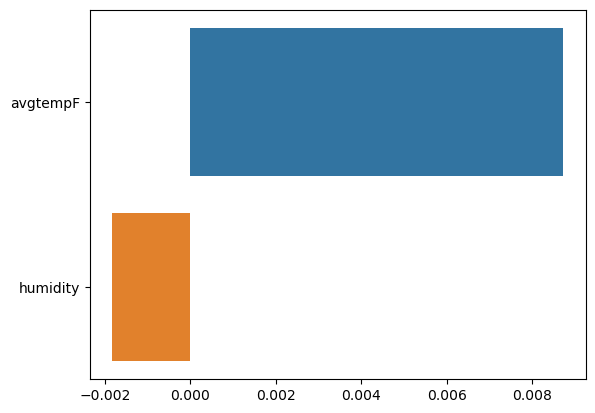

In [246]:
coeff74 = model74.params
coeff74 = coeff74.iloc[(coeff.abs()*-1.0).argsort()]
sns.barplot(x=coeff74.values, y=coeff74.index, orient='h');

In [247]:
X75 = df9[['avgtempF','humidity']]
y75 = df9['VPD']

In [248]:
X75_train,X75_test,y75_train,y75_test=train_test_split(X75,y75,test_size=0.2,random_state=0)

In [249]:
model75 = sm.OLS(y75_train,X75_train).fit()

In [250]:
predictions75 = model75.predict(X75_test)

In [251]:
print_model75 = model75.summary()
print_model75

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                    VPD   R-squared (uncentered):                   0.967
Model:                            OLS   Adj. R-squared (uncentered):              0.966
Method:                 Least Squares   F-statistic:                              1889.
Date:                Tue, 24 Sep 2024   Prob (F-statistic):                    8.45e-97
Time:                        18:36:33   Log-Likelihood:                          119.70
No. Observations:                 132   AIC:                                     -235.4
Df Residuals:                     130   BIC:                                     -229.6
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
avgtempF       0.0164      0.000     32.857      0.000       0.015       0.017
humidity      -0.0063      0.000    -16.144      0.000      -0.007      -0.005
==============================================================================
Omnibus:                       20.308   Durbin-Watson:                   1.969
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               25.918
Skew:                           0.877   Prob(JB):                     2.35e-06
Kurtosis:                       4.279   Cond. No.                         6.88
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

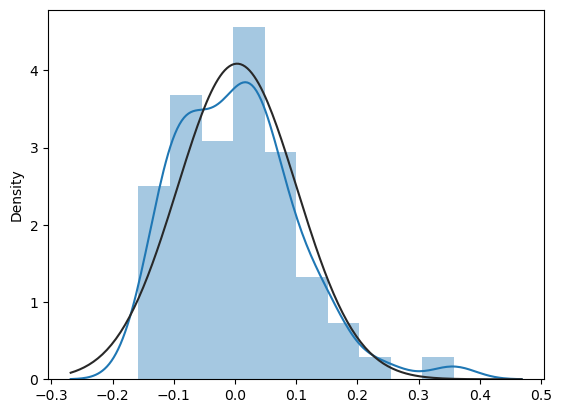

In [252]:
from scipy import stats
sns.distplot(model75.resid, fit=stats.norm);

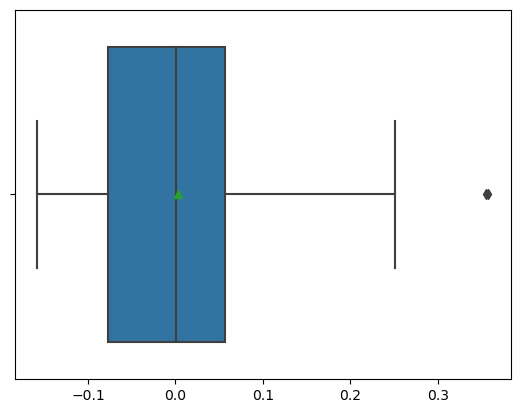

In [253]:
sns.boxplot(model75.resid, showmeans=True);

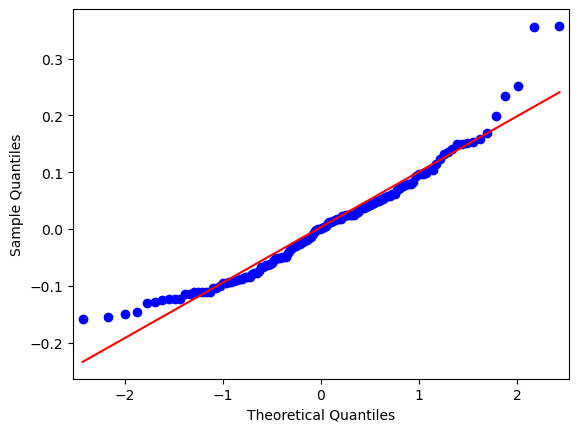

In [254]:
sm.qqplot(model75.resid, line='s');

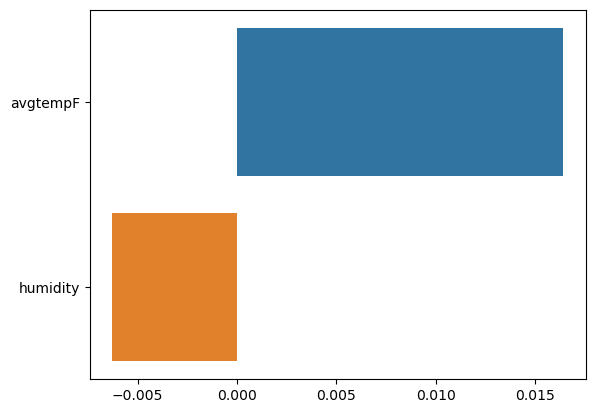

In [255]:
coeff75 = model75.params
coeff75 = coeff75.iloc[(coeff.abs()*-1.0).argsort()]
sns.barplot(x=coeff75.values, y=coeff75.index, orient='h');

In [256]:
X76 = df10[['avgtempF','humidity']]
y76 = df10['VPD']

In [257]:
X76_train,X76_test,y76_train,y76_test=train_test_split(X76,y76,test_size=0.2,random_state=0)

In [258]:
model76 = sm.OLS(y76_train,X76_train).fit()

In [259]:
predictions76 = model76.predict(X76_test)

In [260]:
print_model76 = model76.summary()
print_model76

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                    VPD   R-squared (uncentered):                   0.942
Model:                            OLS   Adj. R-squared (uncentered):              0.941
Method:                 Least Squares   F-statistic:                              1060.
Date:                Tue, 24 Sep 2024   Prob (F-statistic):                    3.20e-81
Time:                        18:36:48   Log-Likelihood:                          49.518
No. Observations:                 132   AIC:                                     -95.04
Df Residuals:                     130   BIC:                                     -89.27
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
avgtempF       0.0213      0.001     28.347      0.000       0.020       0.023
humidity      -0.0096      0.001    -15.212      0.000      -0.011      -0.008
==============================================================================
Omnibus:                        7.930   Durbin-Watson:                   2.019
Prob(Omnibus):                  0.019   Jarque-Bera (JB):                7.778
Skew:                           0.499   Prob(JB):                       0.0205
Kurtosis:                       3.648   Cond. No.                         6.17
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

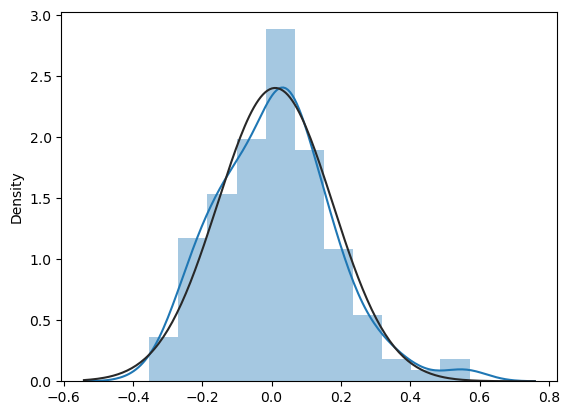

In [261]:
from scipy import stats
sns.distplot(model76.resid, fit=stats.norm);

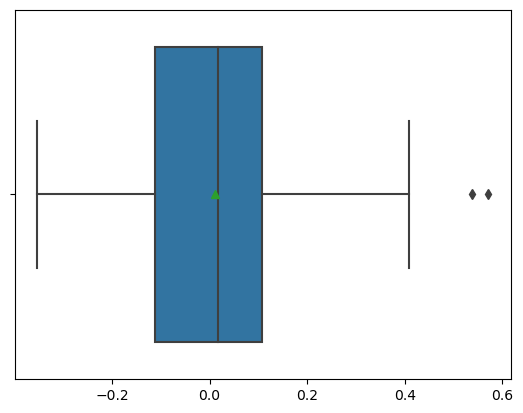

In [262]:
sns.boxplot(model76.resid, showmeans=True);

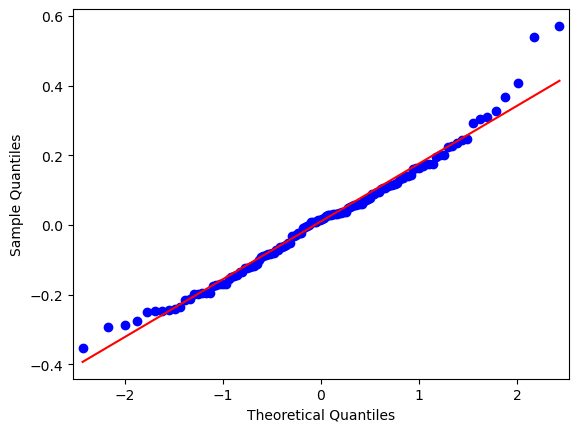

In [263]:
sm.qqplot(model76.resid, line='s');

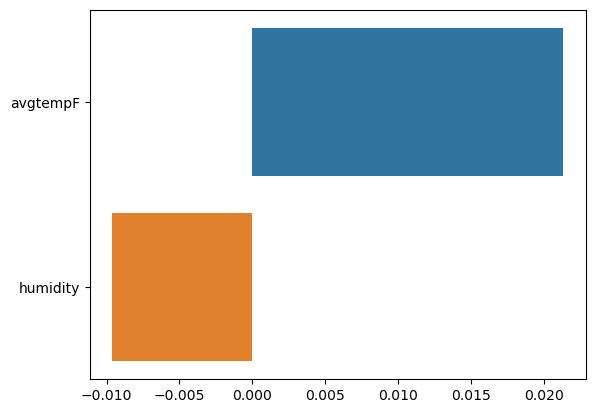

In [264]:
coeff76 = model76.params
coeff76 = coeff76.iloc[(coeff.abs()*-1.0).argsort()]
sns.barplot(x=coeff76.values, y=coeff76.index, orient='h');